# 🌾 KHẢO SÁT & ĐÁNH GIÁ CHI TIẾT TỪNG ĐẶC TRƯNG (FEATURE-BY-FEATURE DEEP DIVE)
### PHỤC VỤ QUYẾT ĐỊNH CHỌN THUỘC TÍNH HUẤN LUYỆN MÔ HÌNH HỒI QUY TUYẾN TÍNH (RICE VISION AI)

---

### 🎯 Mục Tiêu Khảo Sát:
1. **Không tạo đặc trưng nhân tạo**: Khảo sát trực tiếp **toàn bộ 31 thuộc tính gốc** được trích xuất từ dữ liệu thực tế và AI.
2. **Phân tích lần lượt từng Feature qua 3 góc nhìn trực quan**:
   - 📊 **Biểu đồ Phân Bố (Histogram & KDE)**: Đánh giá phân bố giá trị, độ lệch (Skewness), độ nhọn (Kurtosis).
   - 📦 **Biểu đồ Hộp (Boxplot)**: Nhận diện khoảng tứ phân vị (IQR), trung vị, dải giá trị Min-Max và điểm ngoại lai (Outliers).
   - 📈 **Biểu đồ Tương Quan với Nhãn Số Hạt Thực Tế (Scatter Plot + Regression Trendline)**: Kiểm tra trực tiếp quan hệ tuyến tính với `Actual_Count`, tính hệ số $r$, $R^2$, phương trình $y = ax + b$ và $p$-value.
3. **Bảng Tổng Hợp So Sánh Toàn Diện**: Xếp hạng toàn bộ 31 đặc trưng theo mức độ tương quan và sai số dự đoán đơn biến để bạn đưa ra quyết định chọn lựa tốt nhất!


In [11]:
# Bước 1: Kết nối Google Drive & Cài đặt thư viện
from google.colab import drive
import os

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

!pip install pandas numpy matplotlib seaborn scipy scikit-learn openpyxl


In [12]:
# Bước 2: Nạp Dữ Liệu Thực Tế từ final_linear_regression_dataset.csv / .xlsx
import os
import sys
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from pathlib import Path

# Cài đặt giao diện đồ thị khoa học chuẩn mực
sns.set_theme(style="whitegrid", font_scale=1.02)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ĐƯỜNG DẪN DỮ LIỆU
BASE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES"
csv_path = os.path.join(BASE_PATH, "DATASET_BUILDER/4_Final_Dataset/final_linear_regression_dataset.csv")
excel_path = os.path.join(BASE_PATH, "DATASET_BUILDER/4_Final_Dataset/final_linear_regression_dataset.xlsx")

if os.path.exists(csv_path):
    df_raw = pd.read_csv(csv_path)
elif os.path.exists(excel_path):
    df_raw = pd.read_excel(excel_path)
else:
    # Fallback local path
    df_raw = pd.read_csv("DATASET_BUILDER/4_Final_Dataset/final_linear_regression_dataset.csv")

# Lọc chỉ lấy các mẫu có đầy đủ dữ liệu (Image_Status == 'FOUND')
df = df_raw[df_raw['Image_Status'] == 'FOUND'].copy()

# Danh sách tất cả 31 thuộc tính gốc cần khảo sát
ALL_FEATURES = [
    # Nhóm 1: Vật chứa & Thể tích khối lúa
    'Bulk_Rice_Volume_mm3', 'Rice_Height_mm', 'Weight_g', 'Empty_Height_mm',
    'Pixels_Per_mm', 'Container_Detected_Diam_px', 'Inner_Diameter_mm', 'Container_Height_mm',
    # Nhóm 2: Bề mặt & Ước lượng
    'Whole_Grains_Count', 'Uniformity_Rate_Pct', 'Estimated_Total_Seeds_Hybrid',
    # Nhóm 3: Chiều dài hạt (2a)
    'Grain_Length_mm_Mean', 'Grain_Length_mm_Min', 'Grain_Length_mm_Max', 'Grain_Length_mm_Std',
    # Nhóm 4: Chiều rộng hạt (2b)
    'Grain_Width_mm_Mean', 'Grain_Width_mm_Min', 'Grain_Width_mm_Max', 'Grain_Width_mm_Std',
    # Nhóm 5: Chiều dày hạt (2c)
    'Grain_Thickness_mm_Mean', 'Grain_Thickness_mm_Min', 'Grain_Thickness_mm_Max', 'Grain_Thickness_mm_Std',
    # Nhóm 6: Diện tích 2D
    'Grain_Area_mm2_Mean', 'Grain_Area_mm2_Min', 'Grain_Area_mm2_Max', 'Grain_Area_mm2_Std',
    # Nhóm 7: Thể tích 3D Ellipsoid hạt nguyên
    'Grain_Volume_mm3_Mean', 'Grain_Volume_mm3_Min', 'Grain_Volume_mm3_Max', 'Grain_Volume_mm3_Std'
]

# Ép kiểu số cho toàn bộ biến
for col in ALL_FEATURES + ['Actual_Count']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("=" * 90)
print("📊 TỔNG QUAN DỮ LIỆU ĐƯỢC NẠP THÀNH CÔNG:")
print("=" * 90)
print(f"🔹 Tổng số dòng trong file Excel gốc : {len(df_raw)} mẫu")
print(f"🔹 Số mẫu hợp lệ đưa vào phân tích  : {len(df)} mẫu ({len(df)/len(df_raw)*100:.1f}%)")
print(f"🔹 Biến mục tiêu chính (Target Y)   : 'Actual_Count' (Số hạt thực tế)")
print(f"🔹 Tổng số biến độc lập (Features)  : {len(ALL_FEATURES)} thuộc tính gốc")
print("=" * 90)


📊 TỔNG QUAN DỮ LIỆU ĐƯỢC NẠP THÀNH CÔNG:
🔹 Tổng số dòng trong file Excel gốc : 285 mẫu
🔹 Số mẫu hợp lệ đưa vào phân tích  : 254 mẫu (89.1%)
🔹 Biến mục tiêu chính (Target Y)   : 'Actual_Count' (Số hạt thực tế)
🔹 Tổng số biến độc lập (Features)  : 31 thuộc tính gốc


In [13]:
# Bước 3: ĐỊNH NGHĨA HÀM KHẢO SÁT CHUYÊN SÂU 3 BẢNG ĐIỀU KHIỂN CHO TỪNG FEATURE
def inspect_single_feature(df_in, feature_name, feature_desc="", unit=""):
    """
    Vẽ bộ 3 biểu đồ chuẩn và in thẻ thống kê cho 1 feature cụ thể:
    1. Histogram & KDE (Phân bố tần suất)
    2. Boxplot (Trung vị, Tứ phân vị, Ngoại lai)
    3. Scatter Plot vs Actual_Count (Tương quan tuyến tính, đường hồi quy, r, R2, phương trình)
    """
    sub_df = df_in[[feature_name, 'Actual_Count']].dropna()
    if sub_df.empty:
        print(f"⚠️ Không có dữ liệu hợp lệ cho thuộc tính: {feature_name}")
        return

    x = sub_df[feature_name]
    y = sub_df['Actual_Count']

    # 1. Thống kê mô tả
    count_v = len(x)
    mean_v  = x.mean()
    std_v   = x.std()
    min_v   = x.min()
    q25_v   = x.quantile(0.25)
    med_v   = x.median()
    q75_v   = x.quantile(0.75)
    max_v   = x.max()
    skew_v  = x.skew()
    kurt_v  = x.kurtosis()

    # 2. Phân tích tương quan & hồi quy đơn biến
    r_val, p_val = stats.pearsonr(x, y)
    rho_val, _   = stats.spearmanr(x, y)
    r2_val       = r_val ** 2

    # Tính phương trình hồi quy tuyến tính đơn biến y = ax + b
    slope, intercept = np.polyfit(x, y, 1)
    pred_y = slope * x + intercept
    mae_v  = np.mean(np.abs(pred_y - y))
    mape_v = np.mean(np.abs((pred_y - y) / y)) * 100

    # Đánh giá độ mạnh tương quan
    abs_r = abs(r_val)
    if abs_r >= 0.85:
        eval_str = "🌟 CỰC KỲ MẠNH (Ứng viên hàng đầu cho Hồi quy)"
        color_theme = "#1E88E5"
    elif abs_r >= 0.60:
        eval_str = "🟢 RẤT MẠNH (Tương quan tốt)"
        color_theme = "#43A047"
    elif abs_r >= 0.35:
        eval_str = "🟠 TRUNG BÌNH (Có thể dùng làm biến phụ bổ trợ)"
        color_theme = "#FB8C00"
    else:
        eval_str = "⚪ YẾU / NHIỄU (Không nên dùng độc lập)"
        color_theme = "#757575"

    # 3. Vẽ 3 đồ thị nằm ngang
    fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
    unit_str = f" ({unit})" if unit else ""
    title_prefix = f"[{feature_name}] {feature_desc}"

    # Panel 1: Histogram + KDE
    sns.histplot(x, kde=True, ax=axes[0], color=color_theme, edgecolor='black', alpha=0.6, bins=18)
    axes[0].axvline(mean_v, color='red', linestyle='--', linewidth=1.8, label=f'Mean = {mean_v:.2f}')
    axes[0].axvline(med_v, color='blue', linestyle=':', linewidth=1.8, label=f'Median = {med_v:.2f}')
    axes[0].set_title(f"1. Phân Bố Tần Suất (Histogram & KDE)", fontweight='bold', fontsize=11)
    axes[0].set_xlabel(f"{feature_name}{unit_str}")
    axes[0].set_ylabel("Số lượng mẫu")
    axes[0].legend(fontsize=9)

    # Panel 2: Boxplot & Outliers
    sns.boxplot(x=x, ax=axes[1], color=color_theme, fliersize=5)
    axes[1].set_title(f"2. Biểu Đồ Hộp (Boxplot & Ngoại Lai)", fontweight='bold', fontsize=11)
    axes[1].set_xlabel(f"{feature_name}{unit_str}")

    # Panel 3: Scatter Plot vs Actual_Count
    sns.regplot(x=x, y=y, ax=axes[2], color=color_theme, scatter_kws={'alpha': 0.65, 's': 40},
                line_kws={'color': 'red', 'linewidth': 2})
    sign_str = '+' if intercept >= 0 else '-'
    axes[2].set_title(f"3. Tương Quan Tuyến Tính vs Actual_Count\n(r = {r_val:+.4f} | R² = {r2_val:.4f})", fontweight='bold', fontsize=11)
    axes[2].set_xlabel(f"{feature_name}{unit_str}")
    axes[2].set_ylabel("Actual_Count (Số hạt thực tế)")

    plt.suptitle(f"📌 KHẢO SÁT ĐẶC TRƯNG: {feature_name.upper()} {unit_str}", fontweight='bold', fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()

    # 4. In thẻ tóm tắt chi tiết
    print("┌" + "─" * 92 + "┐")
    print(f"│ 📋 THÔNG SỐ CHI TIẾT: {feature_name:<30} {unit_str:<10} N = {count_v:<4} mẫu{'':<23}│")
    print("├" + "─" * 92 + "┤")
    print(f"│  • Thống kê phân bố : Mean = {mean_v:<8.2f} | Std = {std_v:<8.2f} | Min = {min_v:<8.2f} | Max = {max_v:<8.2f}     │")
    print(f"│  • Tứ phân vị (IQR) : 25% = {q25_v:<9.2f} | Median = {med_v:<6.2f} | 75% = {q75_v:<8.2f} | Skewness = {skew_v:<6.2f} │")
    print(f"│  • Tương quan Tuyến : Pearson r = {r_val:<+8.4f} (R² = {r2_val:<6.4f}) | Spearman rho = {rho_val:<+8.4f} (p = {p_val:.2e}) │")
    print(f"│  • Hồi quy Đơn biến : Actual_Count = {slope:.5f} * X {sign_str} {abs(intercept):.2f} | MAE = {mae_v:.2f} hạt (MAPE = {mape_v:.2f}%)  │")
    print(f"│  • Đánh giá mức độ  : {eval_str:<70}│")
    print("└" + "─" * 92 + "┘\n")

print("✅ Đã khởi tạo thành công hàm vẽ bảng điều khiển khảo sát đặc trưng!")


✅ Đã khởi tạo thành công hàm vẽ bảng điều khiển khảo sát đặc trưng!


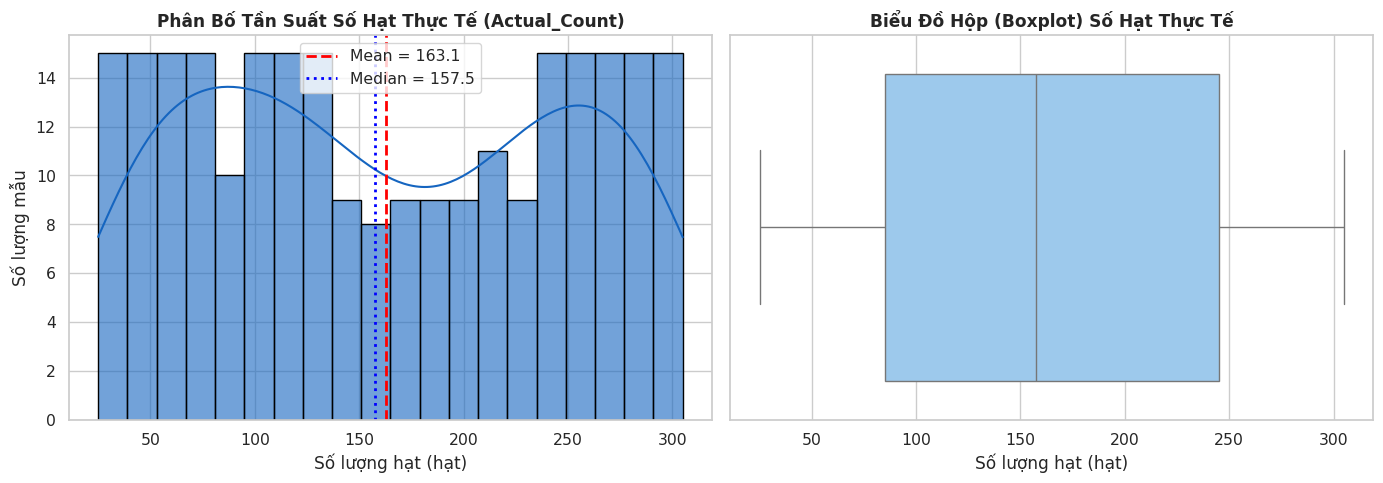

🎯 [TỔNG KẾT BIẾN MỤC TIÊU Actual_Count]:
   • Số mẫu hợp lệ     : 254 mẫu
   • Dải số lượng hạt  : Từ 25 hạt đến 305 hạt (Trung bình: 163.1 hạt, Trung vị: 157.5 hạt)
   • Độ lệch chuẩn     : 86.7 hạt | Độ lệch Skewness = 0.06


In [14]:
# Bước 4: KHẢO SÁT BIẾN MỤC TIÊU CHÍNH (TARGET Y): 'Actual_Count' (SỐ HẠT THỰC TẾ)
# ─────────────────────────────────────────────────────────────────────────────
y = df['Actual_Count'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y, kde=True, ax=axes[0], color='#1565C0', edgecolor='black', alpha=0.6, bins=20)
axes[0].axvline(y.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {y.mean():.1f}')
axes[0].axvline(y.median(), color='blue', linestyle=':', linewidth=2, label=f'Median = {y.median():.1f}')
axes[0].set_title("Phân Bố Tần Suất Số Hạt Thực Tế (Actual_Count)", fontweight='bold')
axes[0].set_xlabel("Số lượng hạt (hạt)")
axes[0].set_ylabel("Số lượng mẫu")
axes[0].legend()

sns.boxplot(x=y, ax=axes[1], color='#90CAF9')
axes[1].set_title("Biểu Đồ Hộp (Boxplot) Số Hạt Thực Tế", fontweight='bold')
axes[1].set_xlabel("Số lượng hạt (hạt)")
plt.tight_layout()
plt.show()

print(f"🎯 [TỔNG KẾT BIẾN MỤC TIÊU Actual_Count]:")
print(f"   • Số mẫu hợp lệ     : {len(y)} mẫu")
print(f"   • Dải số lượng hạt  : Từ {y.min():.0f} hạt đến {y.max():.0f} hạt (Trung bình: {y.mean():.1f} hạt, Trung vị: {y.median():.1f} hạt)")
print(f"   • Độ lệch chuẩn     : {y.std():.1f} hạt | Độ lệch Skewness = {y.skew():.2f}")


📦 BẮT ĐẦU KHẢO SÁT NHÓM 1: THÔNG SỐ VẬT CHỨA & THỂ TÍCH KHỐI LÚA



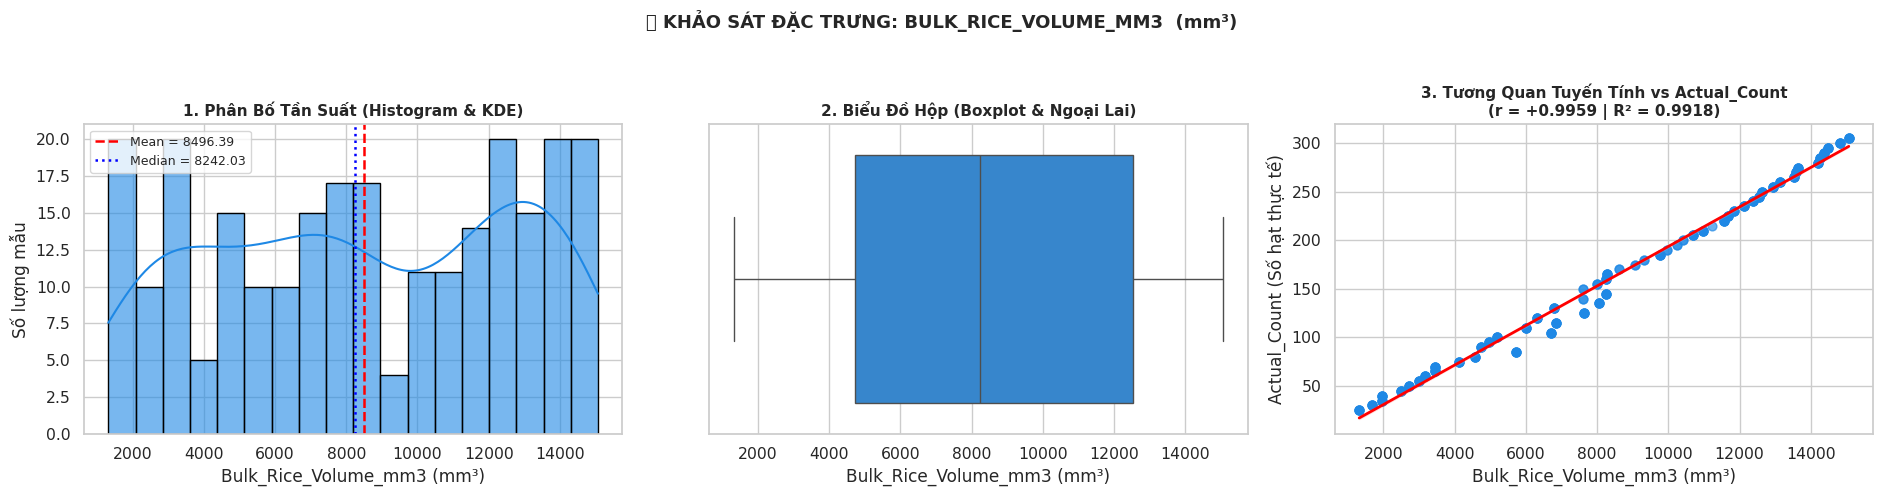

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Bulk_Rice_Volume_mm3            (mm³)     N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 8496.39  | Std = 4241.53  | Min = 1318.88  | Max = 15065.58     │
│  • Tứ phân vị (IQR) : 25% = 4728.07   | Median = 8242.03 | 75% = 12534.24 | Skewness = -0.07  │
│  • Tương quan Tuyến : Pearson r = +0.9959  (R² = 0.9918) | Spearman rho = +0.9980  (p = 1.22e-264) │
│  • Hồi quy Đơn biến : Actual_Count = 0.02035 * X - 9.84 | MAE = 5.74 hạt (MAPE = 6.06%)  │
│  • Đánh giá mức độ  : 🌟 CỰC KỲ MẠNH (Ứng viên hàng đầu cho Hồi quy)                         │
└────────────────────────────────────────────────────────────────────────────────────────────┘



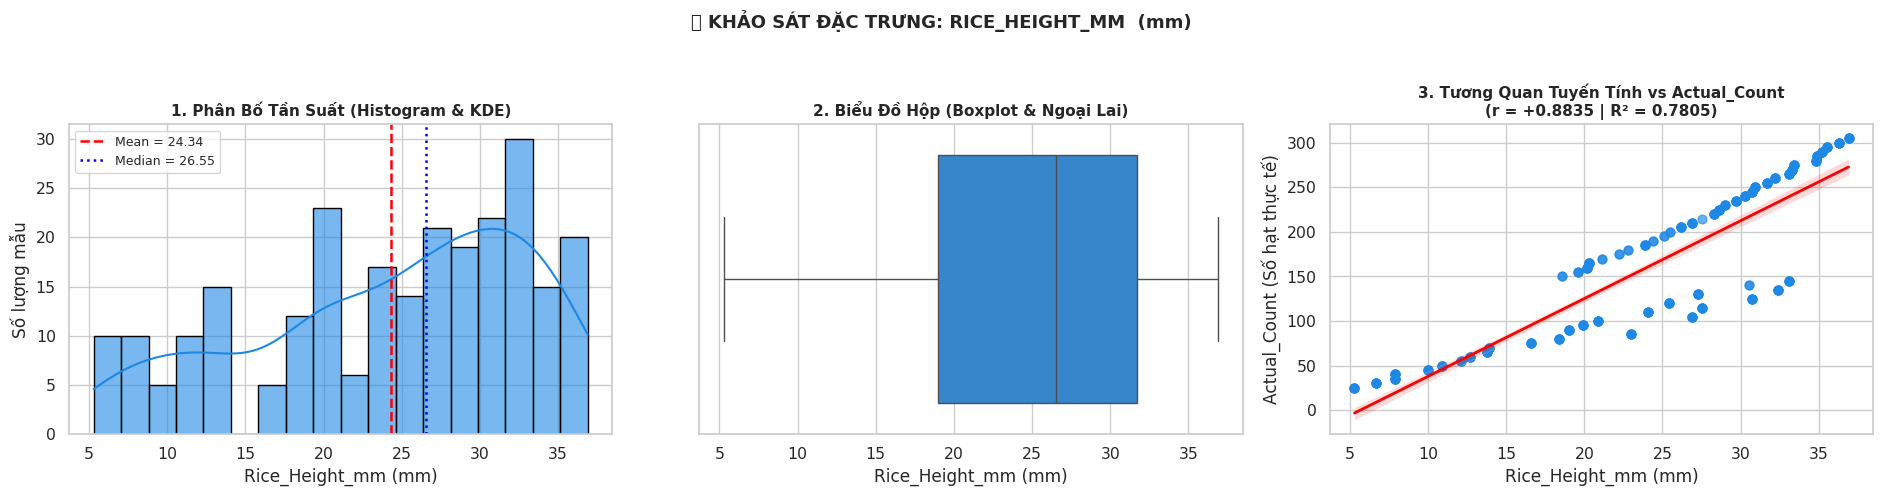

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Rice_Height_mm                  (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 24.34    | Std = 8.76     | Min = 5.30     | Max = 36.90        │
│  • Tứ phân vị (IQR) : 25% = 19.00     | Median = 26.55  | 75% = 31.70    | Skewness = -0.57  │
│  • Tương quan Tuyến : Pearson r = +0.8835  (R² = 0.7805) | Spearman rho = +0.9088  (p = 5.99e-85) │
│  • Hồi quy Đơn biến : Actual_Count = 8.74031 * X - 49.61 | MAE = 33.62 hạt (MAPE = 27.68%)  │
│  • Đánh giá mức độ  : 🌟 CỰC KỲ MẠNH (Ứng viên hàng đầu cho Hồi quy)                         │
└────────────────────────────────────────────────────────────────────────────────────────────┘



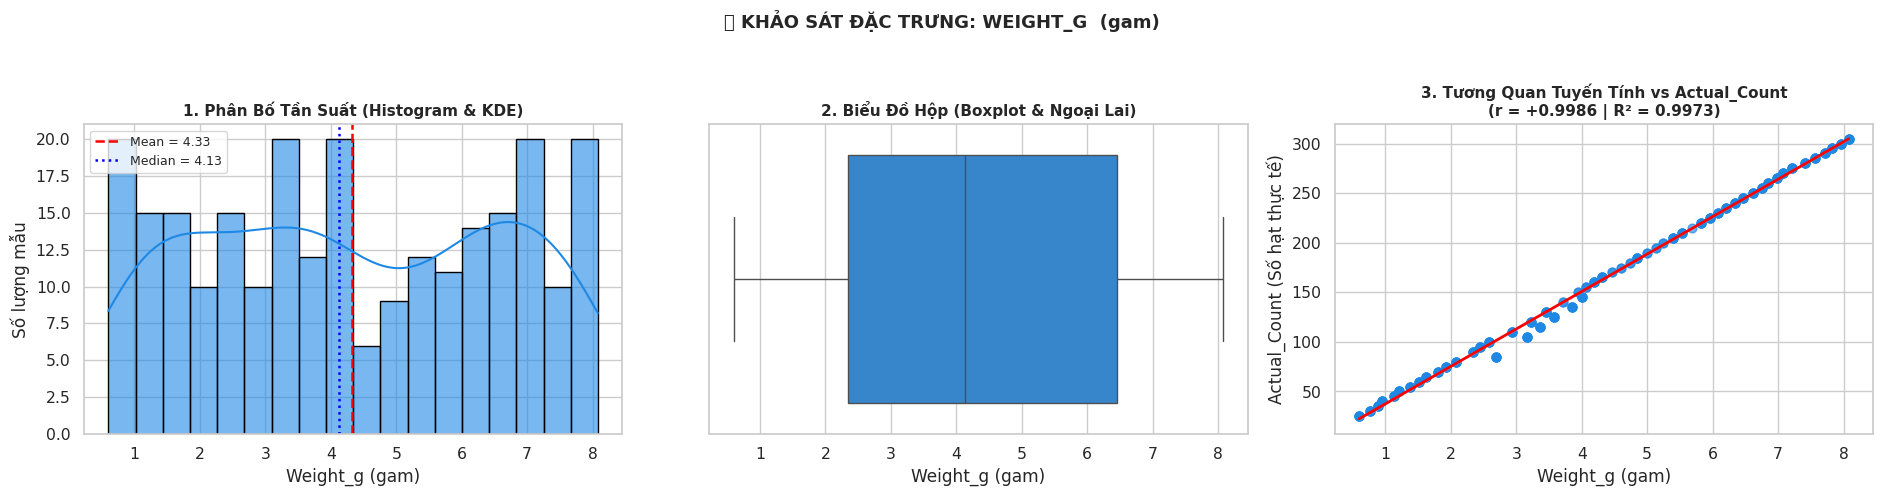

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Weight_g                        (gam)     N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 4.33     | Std = 2.29     | Min = 0.60     | Max = 8.08         │
│  • Tứ phân vị (IQR) : 25% = 2.34      | Median = 4.13   | 75% = 6.46     | Skewness = 0.02   │
│  • Tương quan Tuyến : Pearson r = +0.9986  (R² = 0.9973) | Spearman rho = +0.9991  (p = 0.00e+00) │
│  • Hồi quy Đơn biến : Actual_Count = 37.73823 * X - 0.15 | MAE = 2.86 hạt (MAPE = 3.11%)  │
│  • Đánh giá mức độ  : 🌟 CỰC KỲ MẠNH (Ứng viên hàng đầu cho Hồi quy)                         │
└────────────────────────────────────────────────────────────────────────────────────────────┘



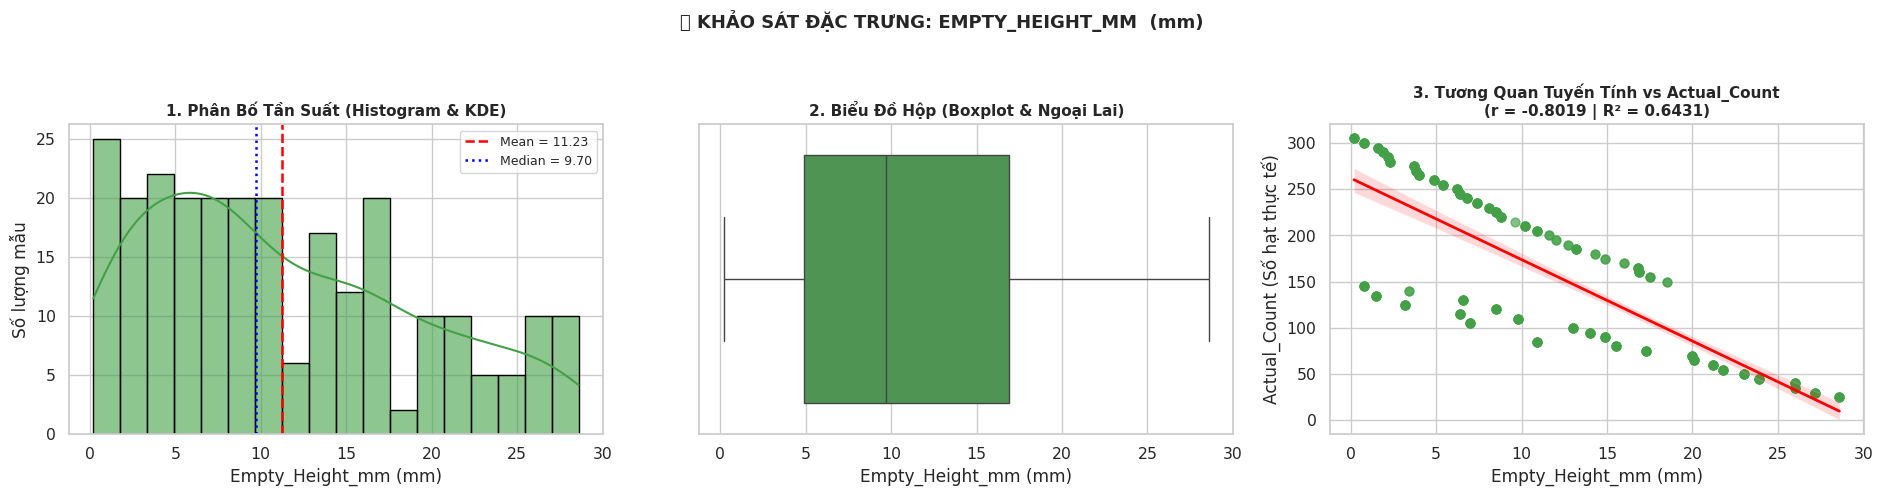

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Empty_Height_mm                 (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 11.23    | Std = 7.89     | Min = 0.20     | Max = 28.60        │
│  • Tứ phân vị (IQR) : 25% = 4.90      | Median = 9.70   | 75% = 16.90    | Skewness = 0.54   │
│  • Tương quan Tuyến : Pearson r = -0.8019  (R² = 0.6431) | Spearman rho = -0.8109  (p = 2.60e-58) │
│  • Hồi quy Đơn biến : Actual_Count = -8.81147 * X + 262.02 | MAE = 44.75 hạt (MAPE = 33.26%)  │
│  • Đánh giá mức độ  : 🟢 RẤT MẠNH (Tương quan tốt)                                           │
└────────────────────────────────────────────────────────────────────────────────────────────┘



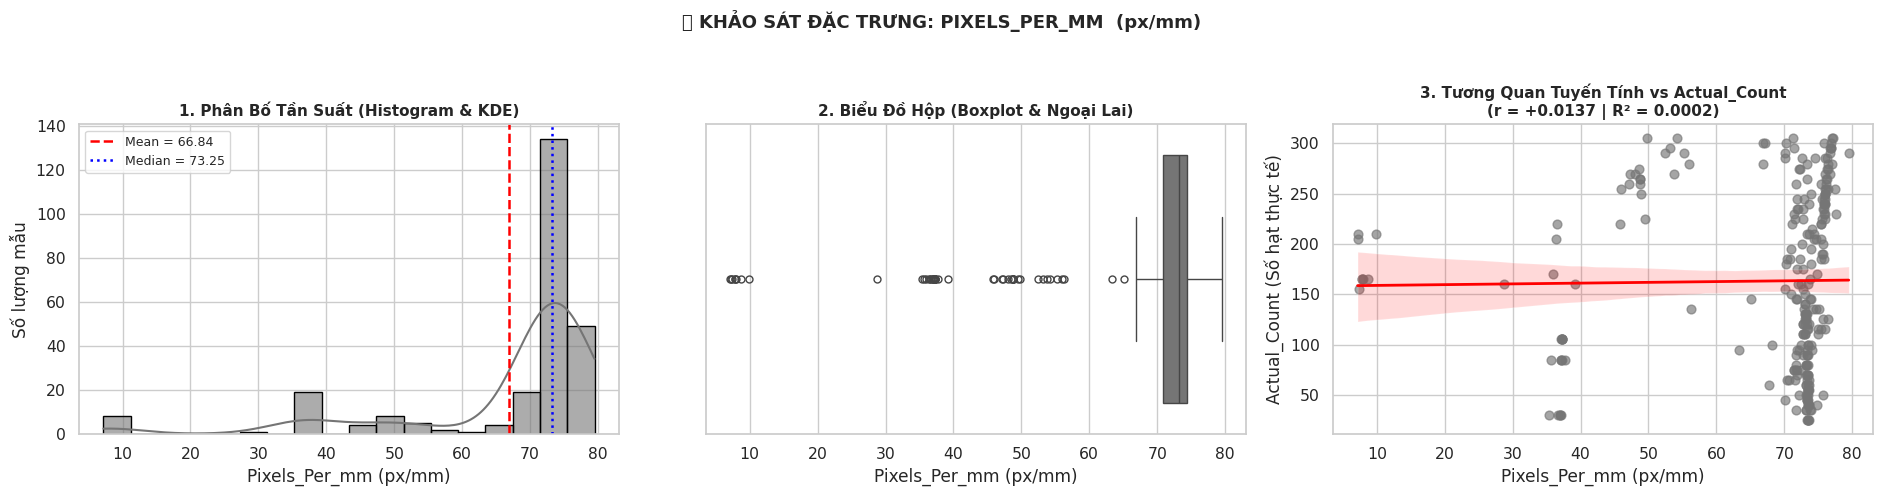

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Pixels_Per_mm                   (px/mm)   N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 66.84    | Std = 15.62    | Min = 7.18     | Max = 79.48        │
│  • Tứ phân vị (IQR) : 25% = 70.89     | Median = 73.25  | 75% = 74.39    | Skewness = -2.31  │
│  • Tương quan Tuyến : Pearson r = +0.0137  (R² = 0.0002) | Spearman rho = +0.1536  (p = 8.28e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 0.07590 * X + 158.02 | MAE = 76.90 hạt (MAPE = 86.25%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



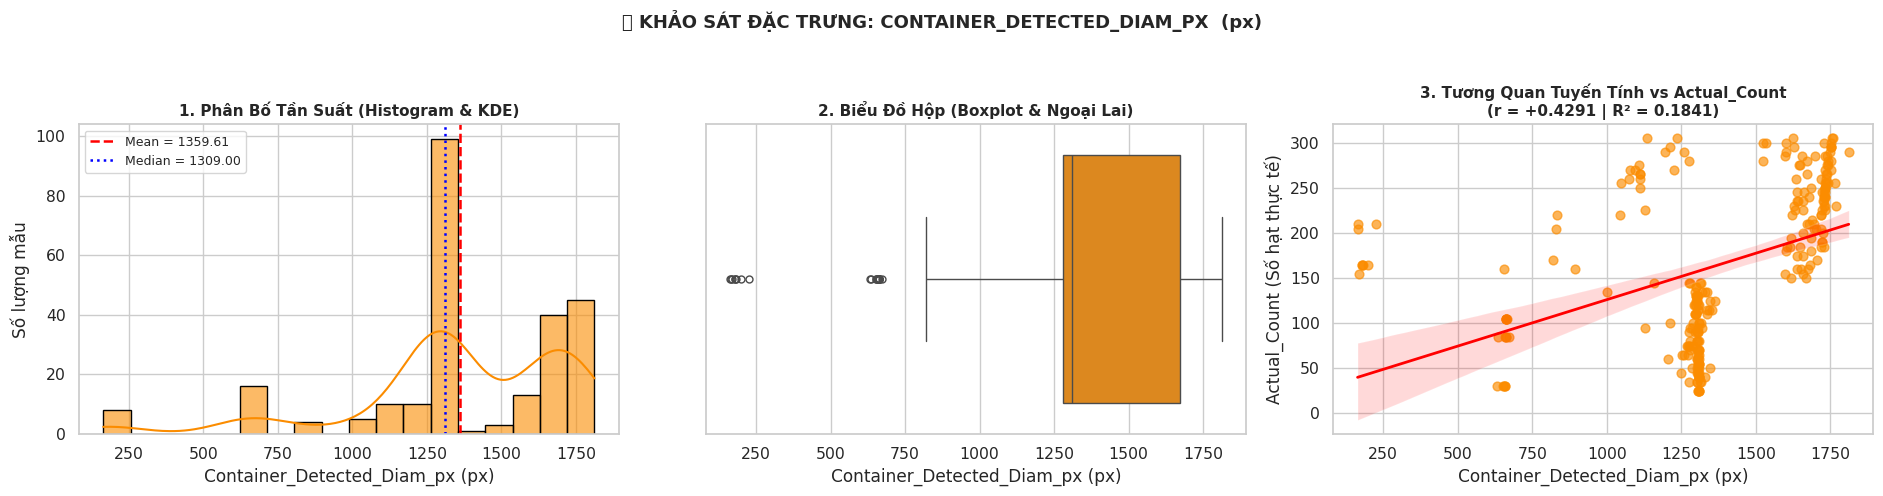

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Container_Detected_Diam_px      (px)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 1359.61  | Std = 361.00   | Min = 164.00   | Max = 1812.00      │
│  • Tứ phân vị (IQR) : 25% = 1280.00   | Median = 1309.00 | 75% = 1672.75  | Skewness = -1.31  │
│  • Tương quan Tuyến : Pearson r = +0.4291  (R² = 0.1841) | Spearman rho = +0.4817  (p = 8.47e-13) │
│  • Hồi quy Đơn biến : Actual_Count = 0.10303 * X + 23.01 | MAE = 66.41 hạt (MAPE = 74.38%)  │
│  • Đánh giá mức độ  : 🟠 TRUNG BÌNH (Có thể dùng làm biến phụ bổ trợ)                        │
└────────────────────────────────────────────────────────────────────────────────────────────┘



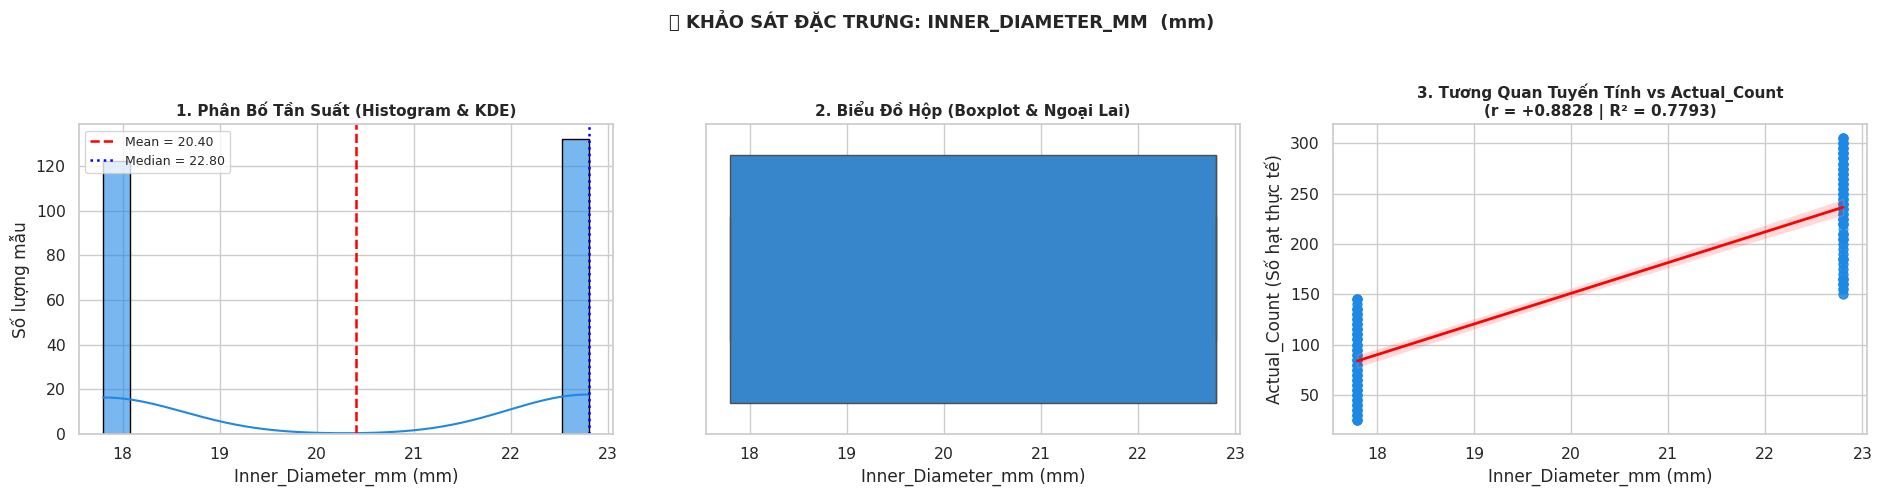

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Inner_Diameter_mm               (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 20.40    | Std = 2.50     | Min = 17.80    | Max = 22.80        │
│  • Tứ phân vị (IQR) : 25% = 17.80     | Median = 22.80  | 75% = 22.80    | Skewness = -0.08  │
│  • Tương quan Tuyến : Pearson r = +0.8828  (R² = 0.7793) | Spearman rho = +0.8655  (p = 1.21e-84) │
│  • Hồi quy Đơn biến : Actual_Count = 30.57352 * X - 460.56 | MAE = 34.55 hạt (MAPE = 34.25%)  │
│  • Đánh giá mức độ  : 🌟 CỰC KỲ MẠNH (Ứng viên hàng đầu cho Hồi quy)                         │
└────────────────────────────────────────────────────────────────────────────────────────────┘



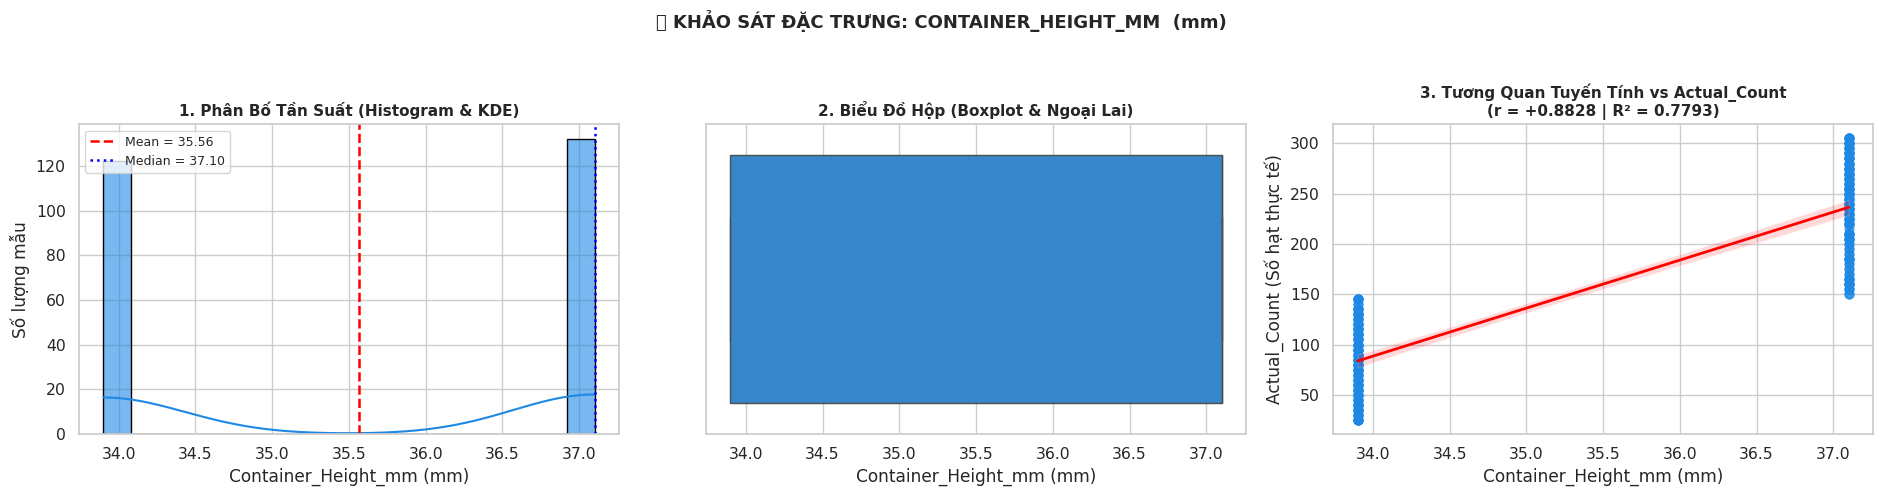

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Container_Height_mm             (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 35.56    | Std = 1.60     | Min = 33.90    | Max = 37.10        │
│  • Tứ phân vị (IQR) : 25% = 33.90     | Median = 37.10  | 75% = 37.10    | Skewness = -0.08  │
│  • Tương quan Tuyến : Pearson r = +0.8828  (R² = 0.7793) | Spearman rho = +0.8655  (p = 1.21e-84) │
│  • Hồi quy Đơn biến : Actual_Count = 47.77113 * X - 1535.79 | MAE = 34.55 hạt (MAPE = 34.25%)  │
│  • Đánh giá mức độ  : 🌟 CỰC KỲ MẠNH (Ứng viên hàng đầu cho Hồi quy)                         │
└────────────────────────────────────────────────────────────────────────────────────────────┘



In [15]:
# =============================================================================
# NHÓM 1: CÁC THÔNG SỐ VẬT CHỨA & THỂ TÍCH KHỐI LÚA (8 THUỘC TÍNH)
# =============================================================================
print("=" * 95)
print("📦 BẮT ĐẦU KHẢO SÁT NHÓM 1: THÔNG SỐ VẬT CHỨA & THỂ TÍCH KHỐI LÚA")
print("=" * 95 + "\n")

# 1. Thể tích khối lúa quang học (Bulk_Rice_Volume_mm3)
inspect_single_feature(df, 'Bulk_Rice_Volume_mm3', 'Thể tích khối lúa tính bằng thị giác máy tính', 'mm³')

# 2. Chiều cao khối lúa thực tế (Rice_Height_mm)
inspect_single_feature(df, 'Rice_Height_mm', 'Chiều cao cột lúa trong ly', 'mm')

# 3. Khối lượng khối lúa (Weight_g) - Cảm biến cân điện tử
inspect_single_feature(df, 'Weight_g', 'Khối lượng mẫu lúa đo bằng cân', 'gam')

# 4. Chiều cao khoảng trống hụt miệng ly (Empty_Height_mm)
inspect_single_feature(df, 'Empty_Height_mm', 'Khoảng cách từ miệng ly đến mặt lúa', 'mm')

# 5. Tỷ lệ quy đổi pixel (Pixels_Per_mm)
inspect_single_feature(df, 'Pixels_Per_mm', 'Tỷ lệ pixel trên mỗi mm thực tế', 'px/mm')

# 6. Đường kính miệng ly phát hiện (Container_Detected_Diam_px)
inspect_single_feature(df, 'Container_Detected_Diam_px', 'Đường kính viền miệng ly bắt được bằng OpenCV', 'px')

# 7. Đường kính trong của ly (Inner_Diameter_mm)
inspect_single_feature(df, 'Inner_Diameter_mm', 'Đường kính mép trong danh định của ly', 'mm')

# 8. Chiều cao toàn bộ thân ly (Container_Height_mm)
inspect_single_feature(df, 'Container_Height_mm', 'Chiều cao thân ly danh định', 'mm')


🌾 BẮT ĐẦU KHẢO SÁT NHÓM 2: THÔNG SỐ BỀ MẶT MIỆNG LY & ĐÁNH GIÁ TỔNG QUAN



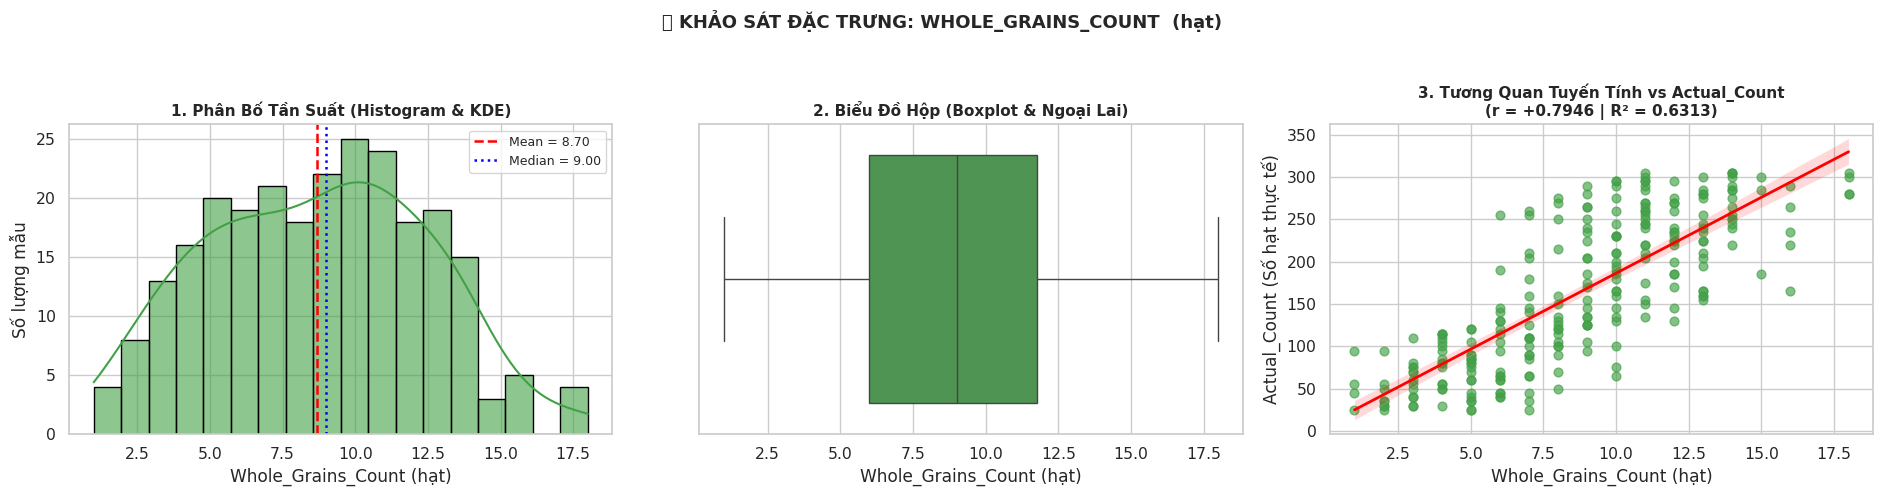

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Whole_Grains_Count              (hạt)     N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 8.70     | Std = 3.84     | Min = 1.00     | Max = 18.00        │
│  • Tứ phân vị (IQR) : 25% = 6.00      | Median = 9.00   | 75% = 11.75    | Skewness = 0.06   │
│  • Tương quan Tuyến : Pearson r = +0.7946  (R² = 0.6313) | Spearman rho = +0.8039  (p = 1.57e-56) │
│  • Hồi quy Đơn biến : Actual_Count = 17.95039 * X + 6.91 | MAE = 41.85 hạt (MAPE = 38.87%)  │
│  • Đánh giá mức độ  : 🟢 RẤT MẠNH (Tương quan tốt)                                           │
└────────────────────────────────────────────────────────────────────────────────────────────┘



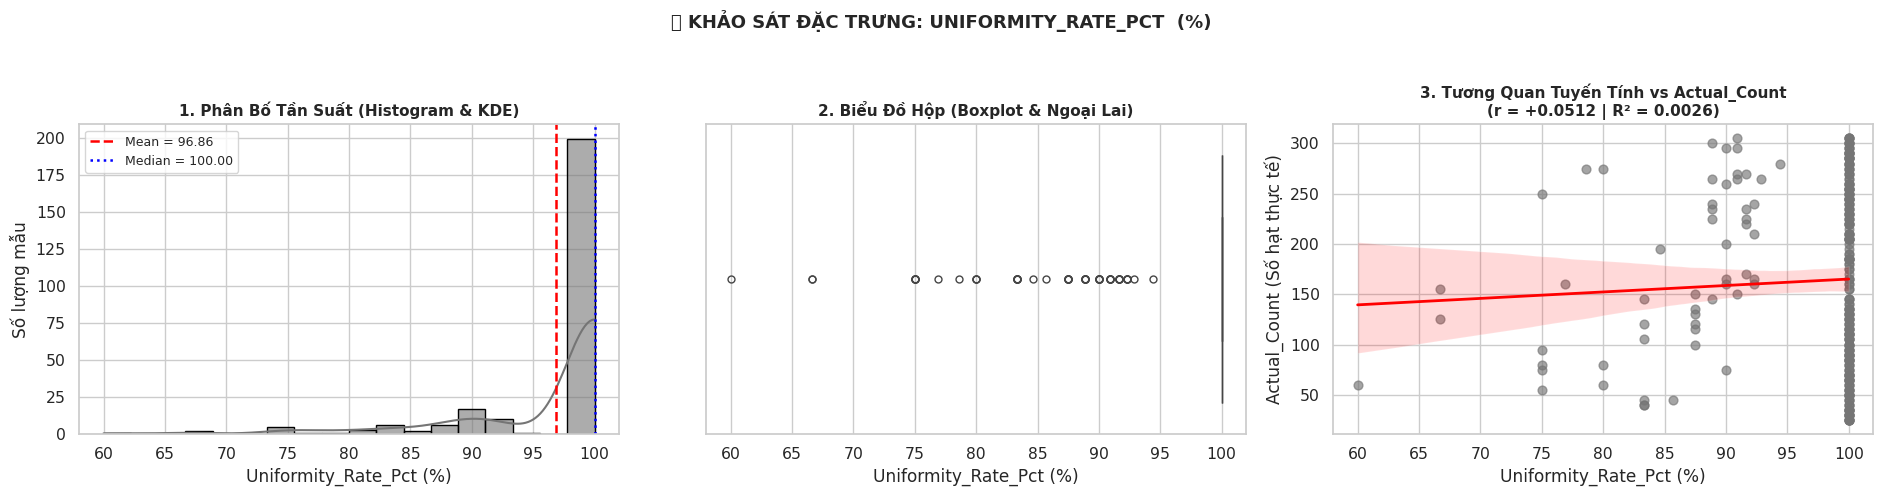

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Uniformity_Rate_Pct             (%)       N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 96.86    | Std = 6.91     | Min = 60.00    | Max = 100.00       │
│  • Tứ phân vị (IQR) : 25% = 100.00    | Median = 100.00 | 75% = 100.00   | Skewness = -2.53  │
│  • Tương quan Tuyến : Pearson r = +0.0512  (R² = 0.0026) | Spearman rho = -0.0319  (p = 4.17e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 0.64180 * X + 100.93 | MAE = 76.55 hạt (MAPE = 86.17%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



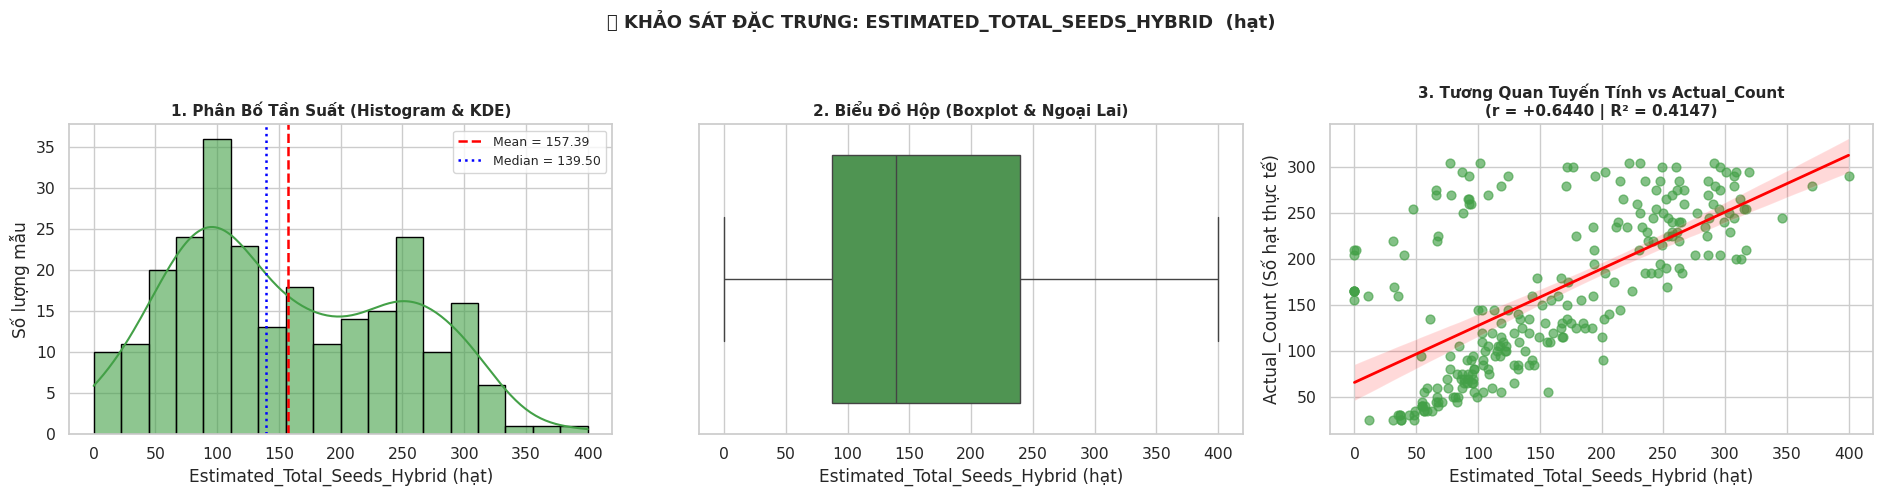

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Estimated_Total_Seeds_Hybrid    (hạt)     N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 157.39   | Std = 90.31    | Min = 0.00     | Max = 400.00       │
│  • Tứ phân vị (IQR) : 25% = 87.25     | Median = 139.50 | 75% = 239.50   | Skewness = 0.29   │
│  • Tương quan Tuyến : Pearson r = +0.6440  (R² = 0.4147) | Spearman rho = +0.6337  (p = 3.76e-31) │
│  • Hồi quy Đơn biến : Actual_Count = 0.61818 * X + 65.79 | MAE = 53.40 hạt (MAPE = 52.45%)  │
│  • Đánh giá mức độ  : 🟢 RẤT MẠNH (Tương quan tốt)                                           │
└────────────────────────────────────────────────────────────────────────────────────────────┘



In [16]:
# =============================================================================
# NHÓM 2: THÔNG SỐ BỀ MẶT MIỆNG LY & ĐÁNH GIÁ TỔNG QUAN (3 THUỘC TÍNH)
# =============================================================================
print("=" * 95)
print("🌾 BẮT ĐẦU KHẢO SÁT NHÓM 2: THÔNG SỐ BỀ MẶT MIỆNG LY & ĐÁNH GIÁ TỔNG QUAN")
print("=" * 95 + "\n")

# 1. Số lượng hạt nguyên thấy trên bề mặt miệng ly (Whole_Grains_Count)
inspect_single_feature(df, 'Whole_Grains_Count', 'Số hạt nguyên được AI phân loại trên mặt ly', 'hạt')

# 2. Độ đồng đều của hạt lúa (Uniformity_Rate_Pct)
inspect_single_feature(df, 'Uniformity_Rate_Pct', 'Tỷ lệ độ đồng đều kích thước hạt theo lọc IQR', '%')

# 3. Ước lượng số hạt theo công thức vật lý cổ điển (Estimated_Total_Seeds_Hybrid)
inspect_single_feature(df, 'Estimated_Total_Seeds_Hybrid', 'Số hạt ước lượng bằng công thức V_bulk * phi / V_grain', 'hạt')


📏 BẮT ĐẦU KHẢO SÁT NHÓM 3: CHIỀU DÀI HẠT NGUYÊN (2a)



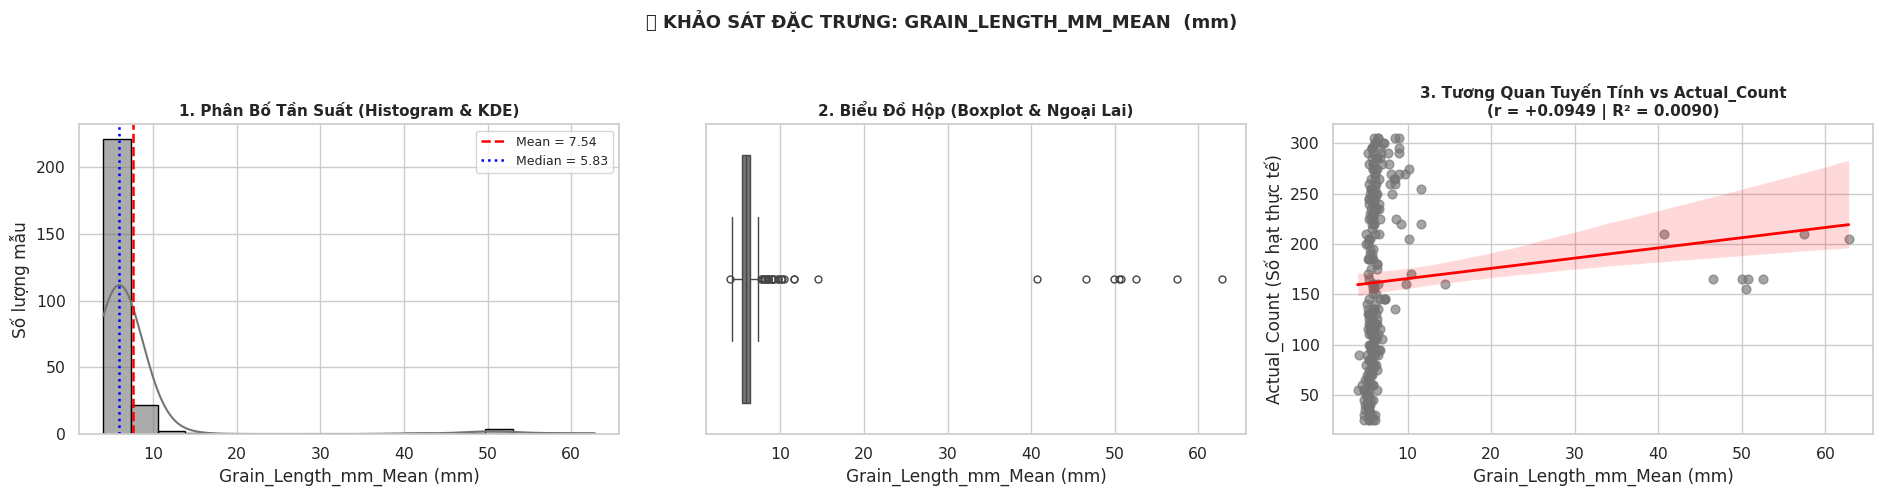

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Length_mm_Mean            (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 7.54     | Std = 8.10     | Min = 4.02     | Max = 62.79        │
│  • Tứ phân vị (IQR) : 25% = 5.43      | Median = 5.83   | 75% = 6.33     | Skewness = 5.37   │
│  • Tương quan Tuyến : Pearson r = +0.0949  (R² = 0.0090) | Spearman rho = +0.5058  (p = 1.31e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 1.01630 * X + 155.42 | MAE = 76.77 hạt (MAPE = 85.19%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



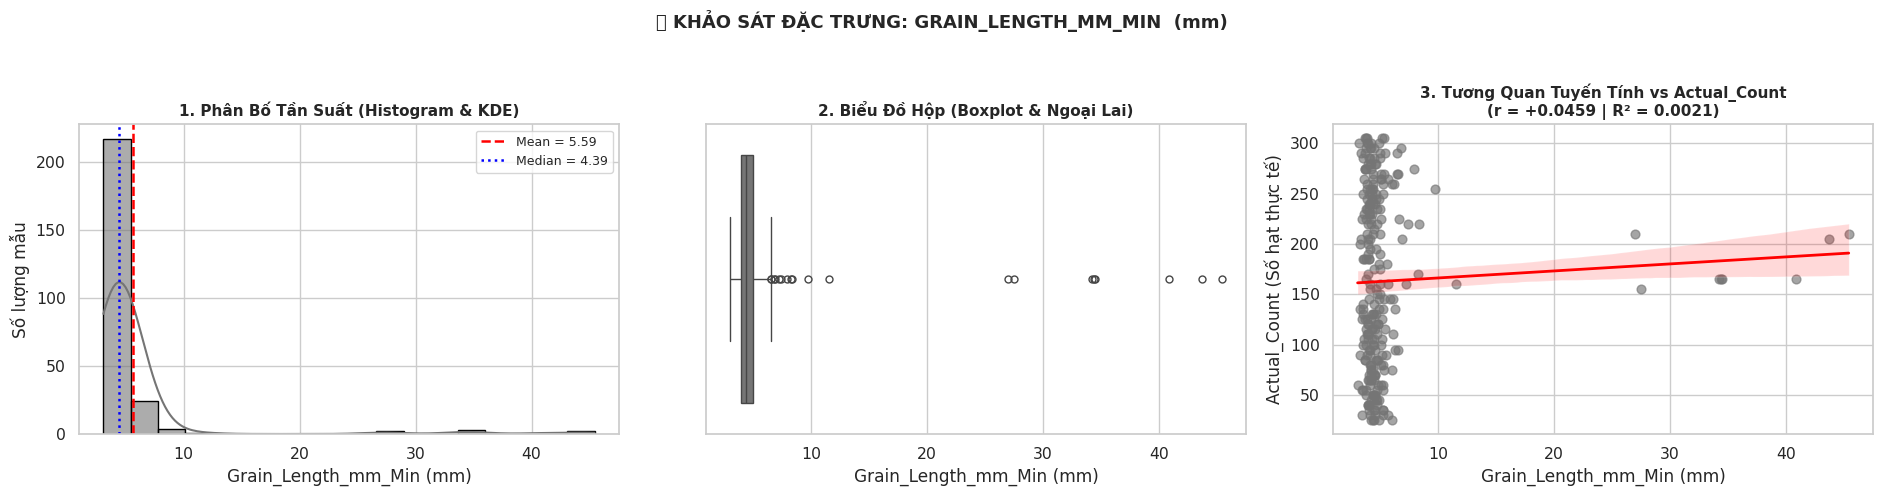

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Length_mm_Min             (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 5.59     | Std = 5.70     | Min = 3.07     | Max = 45.42        │
│  • Tứ phân vị (IQR) : 25% = 4.00      | Median = 4.39   | 75% = 5.02     | Skewness = 5.48   │
│  • Tương quan Tuyến : Pearson r = +0.0459  (R² = 0.0021) | Spearman rho = -0.0295  (p = 4.66e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 0.69860 * X + 159.19 | MAE = 76.84 hạt (MAPE = 85.85%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



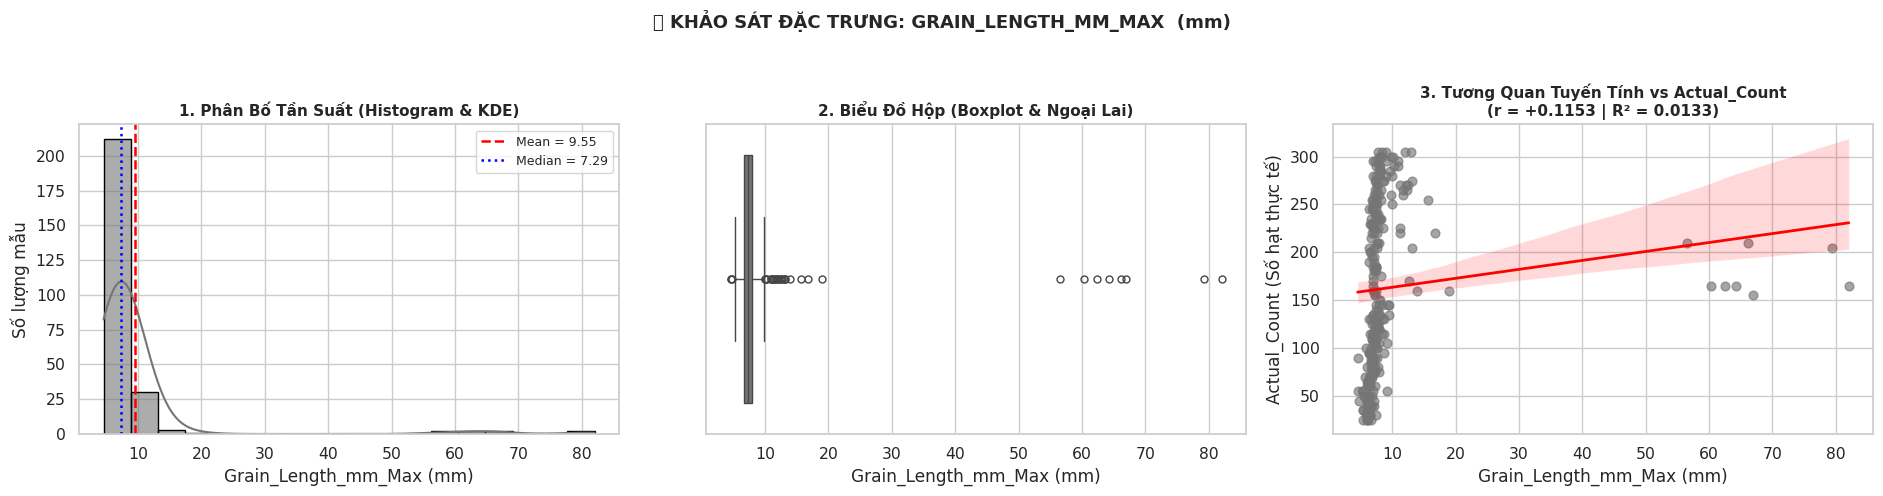

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Length_mm_Max             (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 9.55     | Std = 10.69    | Min = 4.55     | Max = 82.04        │
│  • Tứ phân vị (IQR) : 25% = 6.71      | Median = 7.29   | 75% = 8.01     | Skewness = 5.33   │
│  • Tương quan Tuyến : Pearson r = +0.1153  (R² = 0.0133) | Spearman rho = +0.6288  (p = 6.66e-02) │
│  • Hồi quy Đơn biến : Actual_Count = 0.93460 * X + 154.16 | MAE = 76.73 hạt (MAPE = 84.82%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



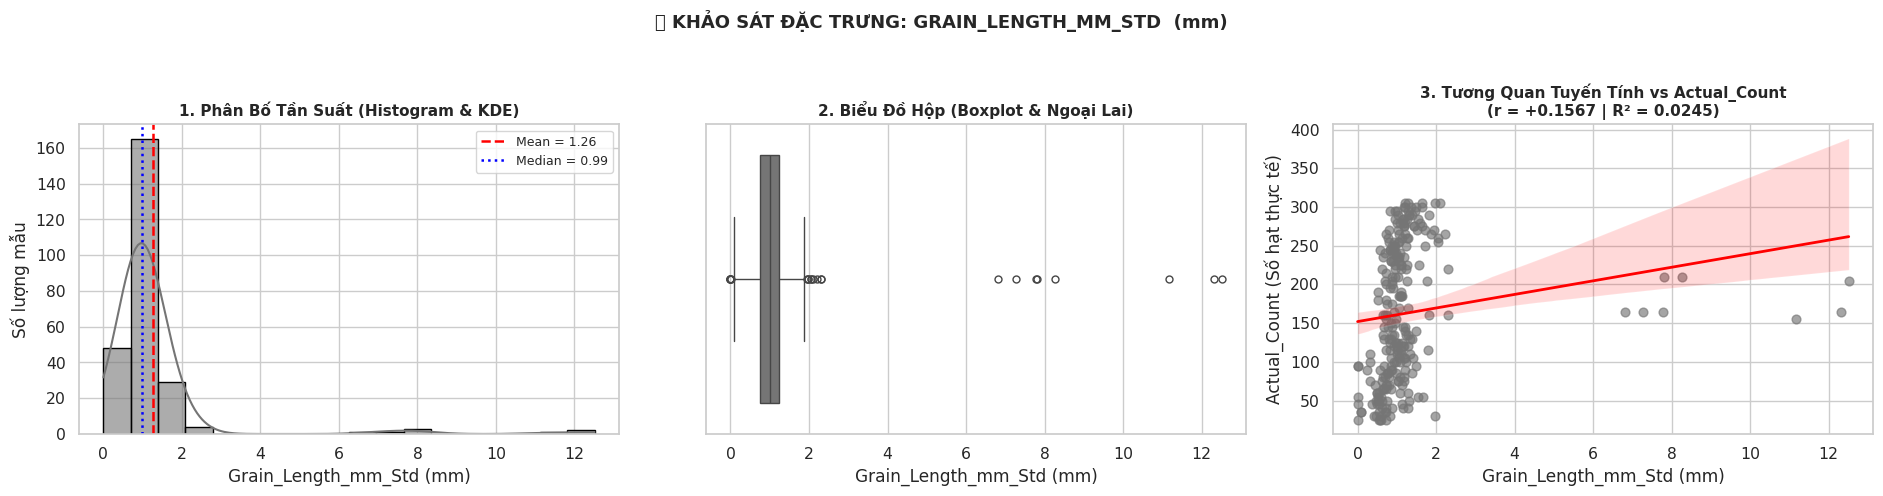

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Length_mm_Std             (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 1.26     | Std = 1.55     | Min = 0.00     | Max = 12.51        │
│  • Tứ phân vị (IQR) : 25% = 0.74      | Median = 0.99   | 75% = 1.23     | Skewness = 5.38   │
│  • Tương quan Tuyến : Pearson r = +0.1567  (R² = 0.0245) | Spearman rho = +0.4876  (p = 1.24e-02) │
│  • Hồi quy Đơn biến : Actual_Count = 8.77282 * X + 152.04 | MAE = 76.59 hạt (MAPE = 83.99%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



In [17]:
# =============================================================================
# NHÓM 3: CHIỀU DÀI HẠT NGUYÊN (2a - LENGTH) (4 THUỘC TÍNH: MEAN, MIN, MAX, STD)
# =============================================================================
print("=" * 95)
print("📏 BẮT ĐẦU KHẢO SÁT NHÓM 3: CHIỀU DÀI HẠT NGUYÊN (2a)")
print("=" * 95 + "\n")

# 1. Chiều dài trung bình hạt (Grain_Length_mm_Mean)
inspect_single_feature(df, 'Grain_Length_mm_Mean', 'Chiều dài trung bình của hạt nguyên (Mean 2a)', 'mm')

# 2. Chiều dài nhỏ nhất (Grain_Length_mm_Min)
inspect_single_feature(df, 'Grain_Length_mm_Min', 'Chiều dài hạt nhỏ nhất trong mẫu (Min 2a)', 'mm')

# 3. Chiều dài lớn nhất (Grain_Length_mm_Max)
inspect_single_feature(df, 'Grain_Length_mm_Max', 'Chiều dài hạt lớn nhất trong mẫu (Max 2a)', 'mm')

# 4. Độ lệch chuẩn chiều dài (Grain_Length_mm_Std)
inspect_single_feature(df, 'Grain_Length_mm_Std', 'Độ biến thiên chiều dài giữa các hạt (Std 2a)', 'mm')


📐 BẮT ĐẦU KHẢO SÁT NHÓM 4: CHIỀU RỘNG HẠT NGUYÊN (2b)



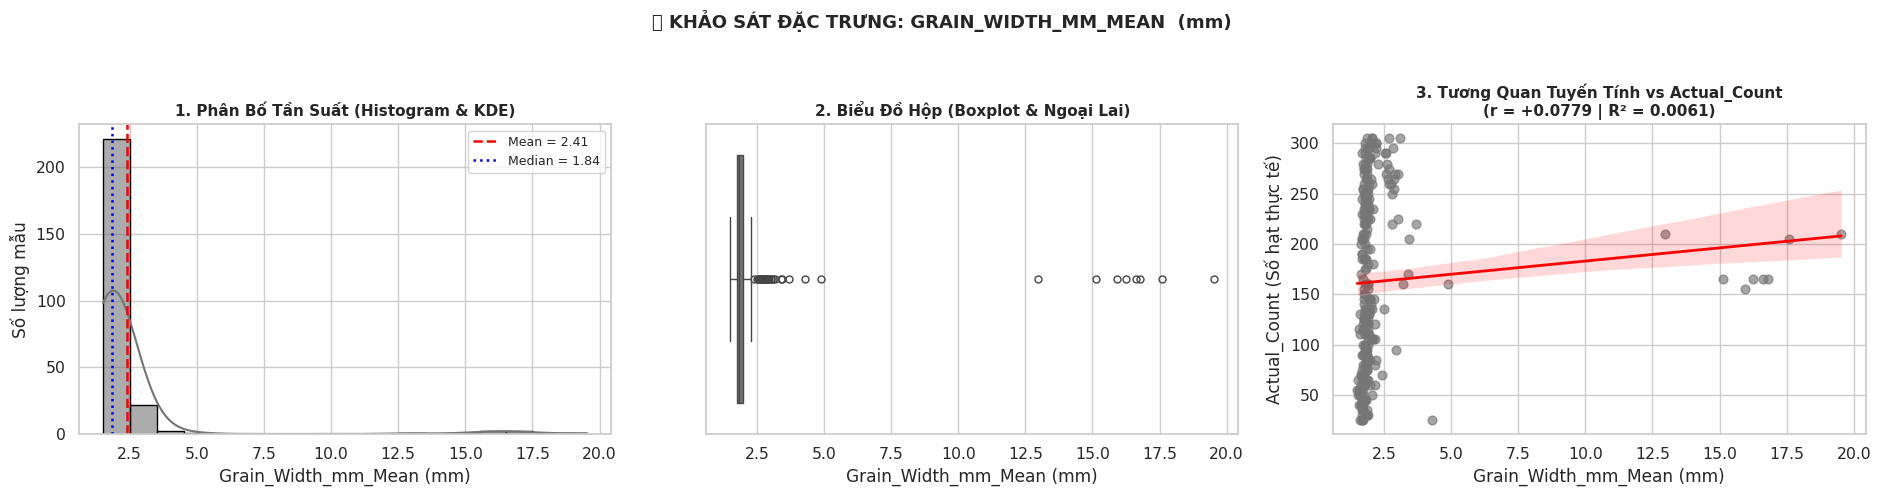

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Width_mm_Mean             (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 2.41     | Std = 2.57     | Min = 1.51     | Max = 19.54        │
│  • Tứ phân vị (IQR) : 25% = 1.75      | Median = 1.84   | 75% = 1.98     | Skewness = 5.31   │
│  • Tương quan Tuyến : Pearson r = +0.0779  (R² = 0.0061) | Spearman rho = +0.3947  (p = 2.16e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 2.62293 * X + 156.77 | MAE = 76.76 hạt (MAPE = 85.47%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



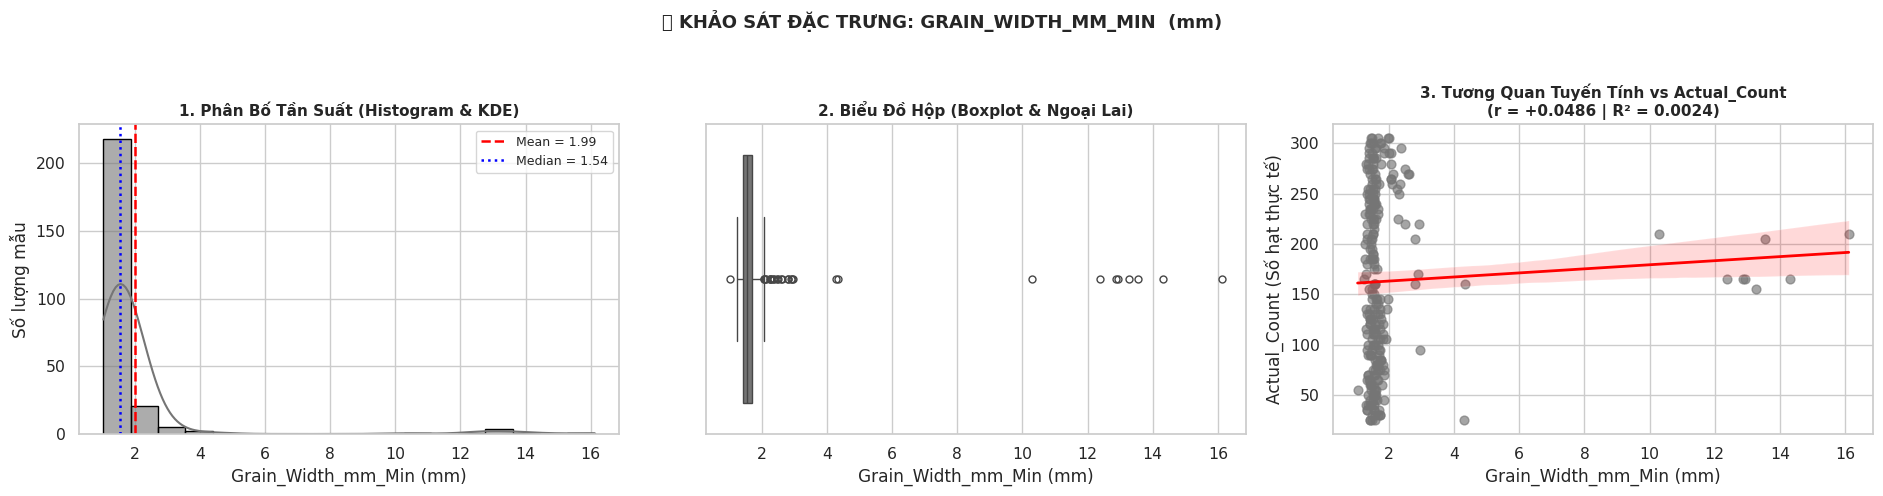

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Width_mm_Min              (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 1.99     | Std = 2.08     | Min = 1.03     | Max = 16.11        │
│  • Tứ phân vị (IQR) : 25% = 1.43      | Median = 1.54   | 75% = 1.69     | Skewness = 5.28   │
│  • Tương quan Tuyến : Pearson r = +0.0486  (R² = 0.0024) | Spearman rho = +0.0549  (p = 4.40e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 2.02494 * X + 159.06 | MAE = 76.88 hạt (MAPE = 85.87%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



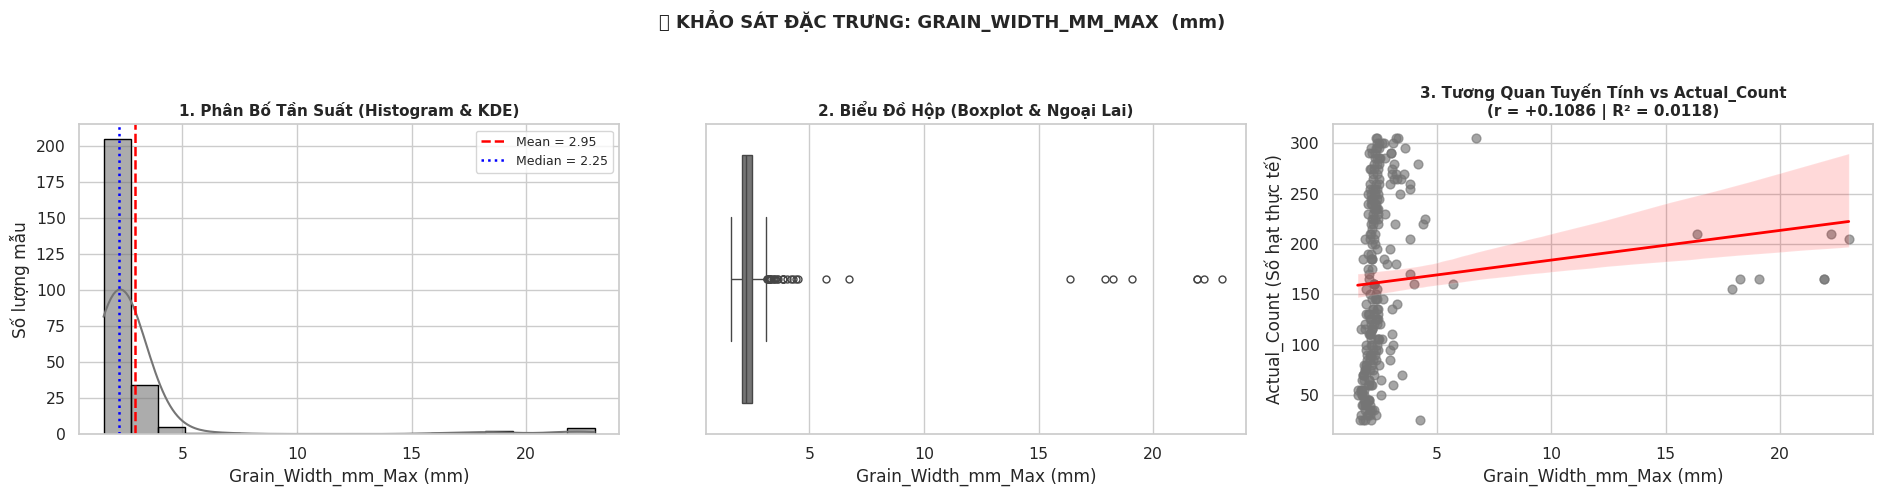

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Width_mm_Max              (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 2.95     | Std = 3.18     | Min = 1.56     | Max = 22.99        │
│  • Tứ phân vị (IQR) : 25% = 2.08      | Median = 2.25   | 75% = 2.49     | Skewness = 5.23   │
│  • Tương quan Tuyến : Pearson r = +0.1086  (R² = 0.0118) | Spearman rho = +0.5212  (p = 8.42e-02) │
│  • Hồi quy Đơn biến : Actual_Count = 2.95805 * X + 154.36 | MAE = 76.73 hạt (MAPE = 85.00%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



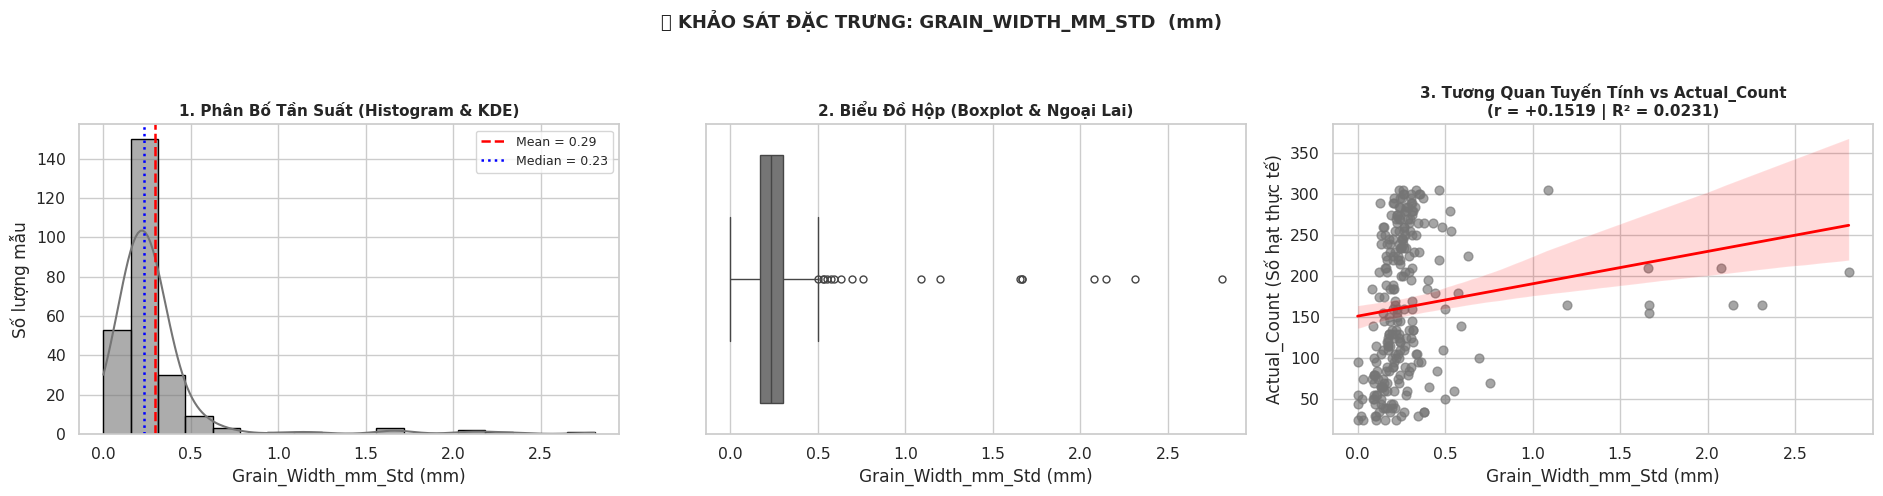

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Width_mm_Std              (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 0.29     | Std = 0.33     | Min = 0.00     | Max = 2.81         │
│  • Tứ phân vị (IQR) : 25% = 0.17      | Median = 0.23   | 75% = 0.30     | Skewness = 4.82   │
│  • Tương quan Tuyến : Pearson r = +0.1519  (R² = 0.0231) | Spearman rho = +0.4032  (p = 1.54e-02) │
│  • Hồi quy Đơn biến : Actual_Count = 39.45955 * X + 151.47 | MAE = 76.46 hạt (MAPE = 84.00%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



In [18]:
# =============================================================================
# NHÓM 4: CHIỀU RỘNG HẠT NGUYÊN (2b - WIDTH) (4 THUỘC TÍNH: MEAN, MIN, MAX, STD)
# =============================================================================
print("=" * 95)
print("📐 BẮT ĐẦU KHẢO SÁT NHÓM 4: CHIỀU RỘNG HẠT NGUYÊN (2b)")
print("=" * 95 + "\n")

# 1. Chiều rộng trung bình hạt (Grain_Width_mm_Mean)
inspect_single_feature(df, 'Grain_Width_mm_Mean', 'Chiều rộng trung bình của hạt nguyên (Mean 2b)', 'mm')

# 2. Chiều rộng nhỏ nhất (Grain_Width_mm_Min)
inspect_single_feature(df, 'Grain_Width_mm_Min', 'Chiều rộng hạt nhỏ nhất trong mẫu (Min 2b)', 'mm')

# 3. Chiều rộng lớn nhất (Grain_Width_mm_Max)
inspect_single_feature(df, 'Grain_Width_mm_Max', 'Chiều rộng hạt lớn nhất trong mẫu (Max 2b)', 'mm')

# 4. Độ lệch chuẩn chiều rộng (Grain_Width_mm_Std)
inspect_single_feature(df, 'Grain_Width_mm_Std', 'Độ biến thiên chiều rộng giữa các hạt (Std 2b)', 'mm')


📏 BẮT ĐẦU KHẢO SÁT NHÓM 5: CHIỀU DÀY HẠT NGUYÊN (2c)



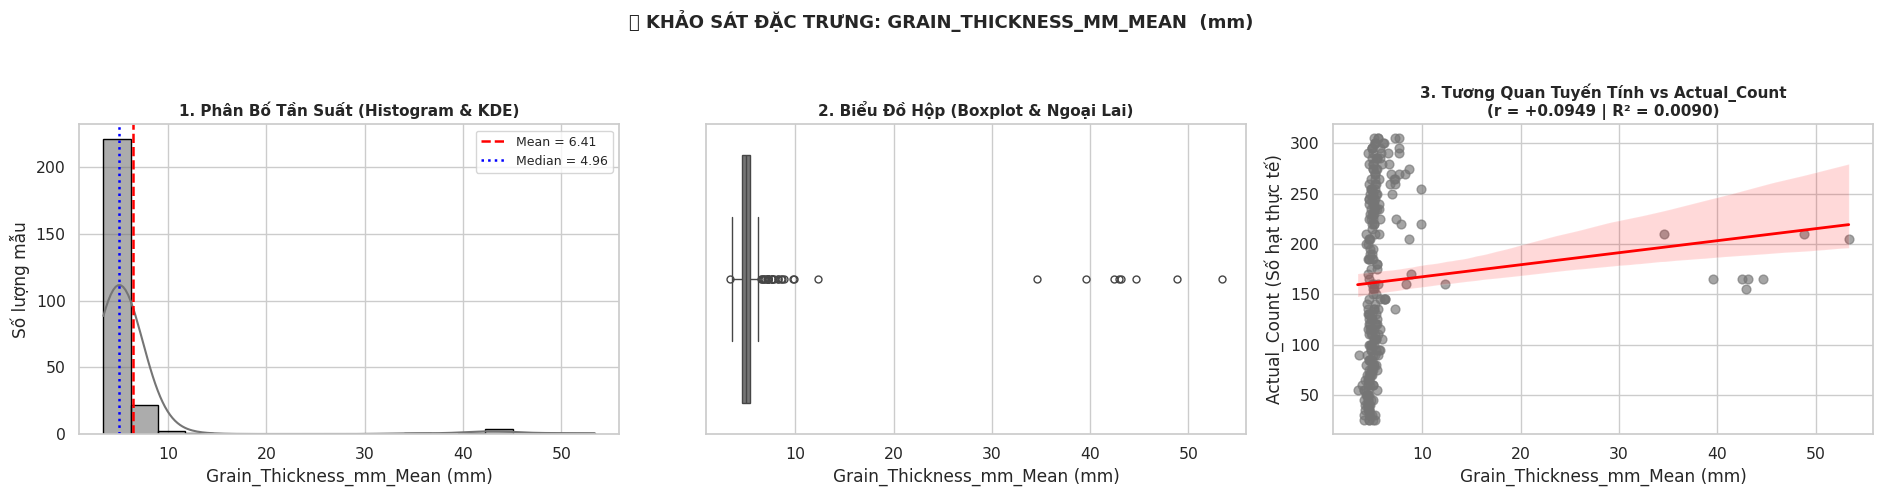

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Thickness_mm_Mean         (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 6.41     | Std = 6.88     | Min = 3.42     | Max = 53.37        │
│  • Tứ phân vị (IQR) : 25% = 4.62      | Median = 4.96   | 75% = 5.38     | Skewness = 5.37   │
│  • Tương quan Tuyến : Pearson r = +0.0949  (R² = 0.0090) | Spearman rho = +0.5059  (p = 1.31e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 1.19564 * X + 155.42 | MAE = 76.77 hạt (MAPE = 85.19%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



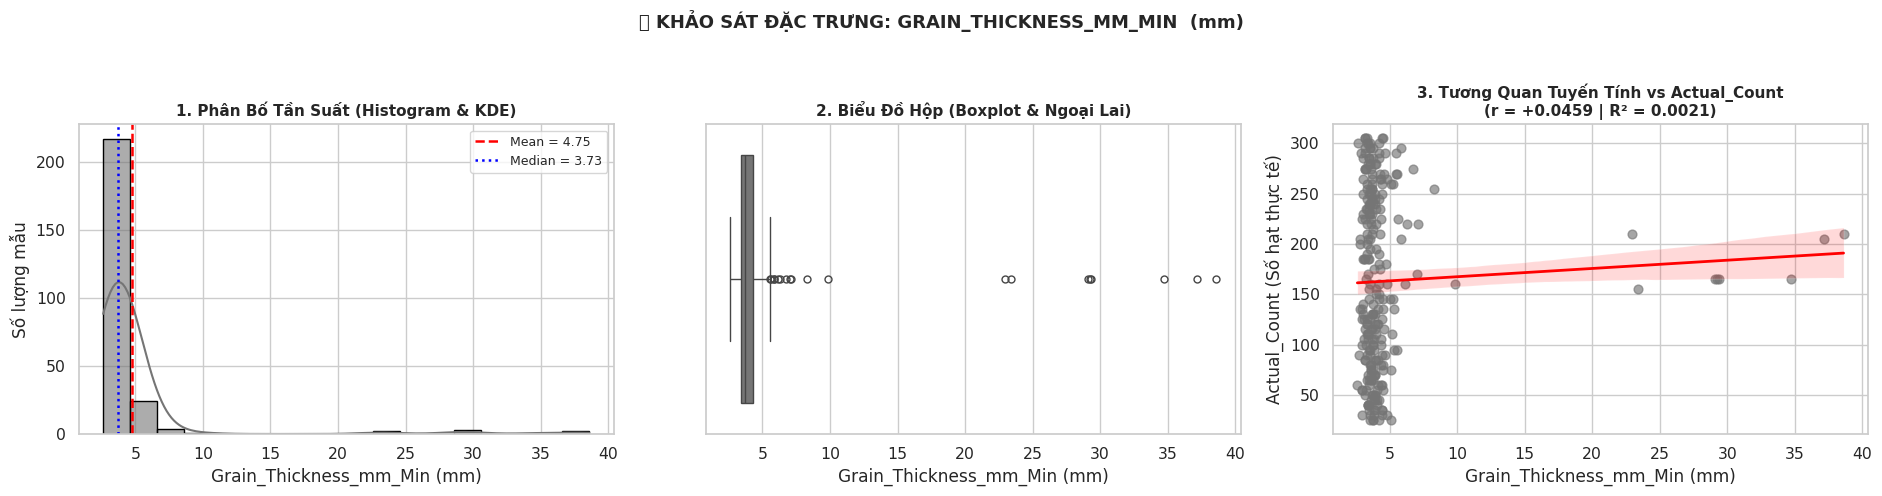

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Thickness_mm_Min          (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 4.75     | Std = 4.84     | Min = 2.61     | Max = 38.61        │
│  • Tứ phân vị (IQR) : 25% = 3.40      | Median = 3.73   | 75% = 4.27     | Skewness = 5.48   │
│  • Tương quan Tuyến : Pearson r = +0.0459  (R² = 0.0021) | Spearman rho = -0.0295  (p = 4.66e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 0.82212 * X + 159.18 | MAE = 76.84 hạt (MAPE = 85.85%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



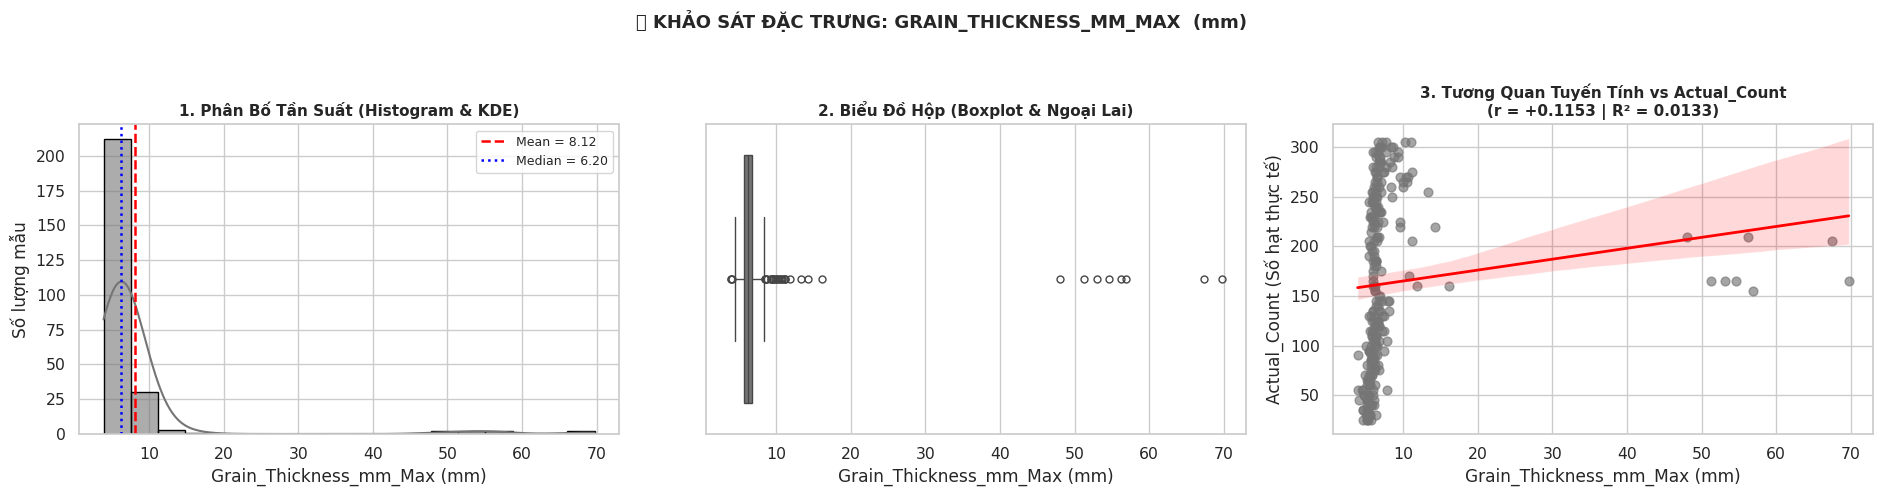

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Thickness_mm_Max          (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 8.12     | Std = 9.09     | Min = 3.87     | Max = 69.73        │
│  • Tứ phân vị (IQR) : 25% = 5.71      | Median = 6.20   | 75% = 6.80     | Skewness = 5.33   │
│  • Tương quan Tuyến : Pearson r = +0.1153  (R² = 0.0133) | Spearman rho = +0.6288  (p = 6.66e-02) │
│  • Hồi quy Đơn biến : Actual_Count = 1.09953 * X + 154.16 | MAE = 76.73 hạt (MAPE = 84.82%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



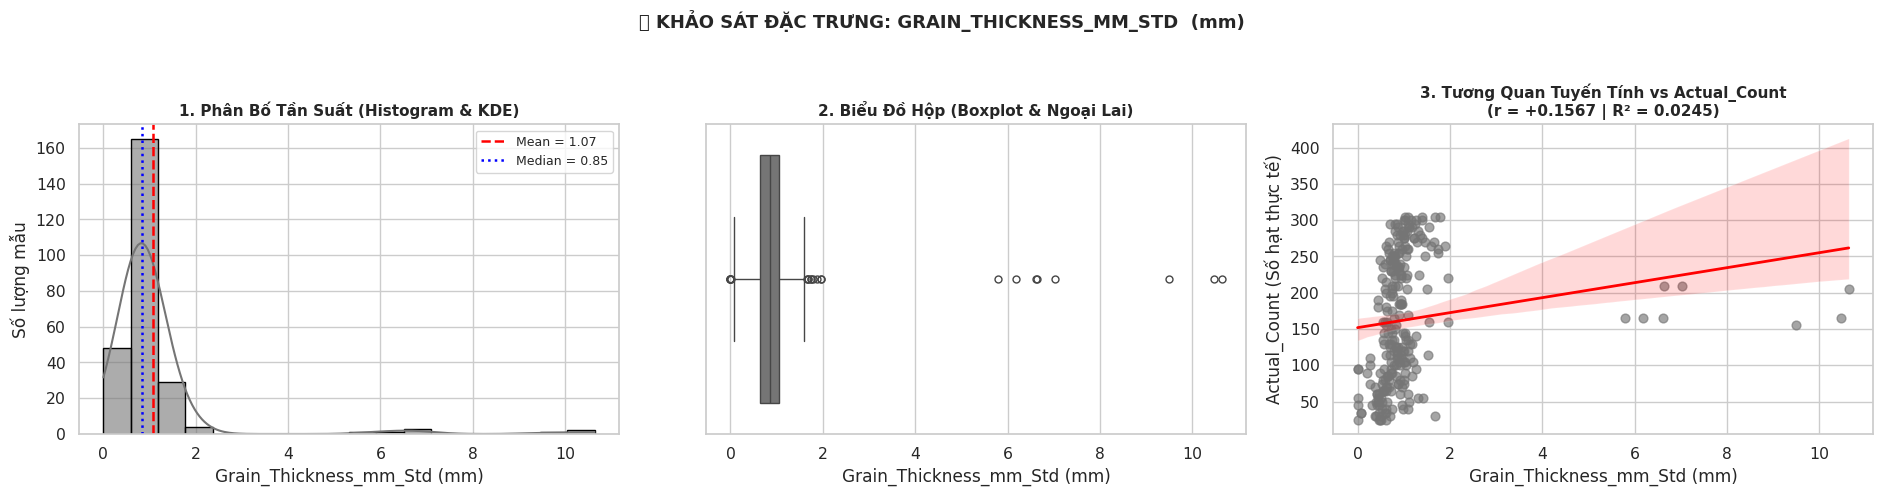

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Thickness_mm_Std          (mm)      N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 1.07     | Std = 1.32     | Min = 0.00     | Max = 10.63        │
│  • Tứ phân vị (IQR) : 25% = 0.63      | Median = 0.85   | 75% = 1.04     | Skewness = 5.38   │
│  • Tương quan Tuyến : Pearson r = +0.1567  (R² = 0.0245) | Spearman rho = +0.4876  (p = 1.24e-02) │
│  • Hồi quy Đơn biến : Actual_Count = 10.32205 * X + 152.04 | MAE = 76.59 hạt (MAPE = 83.99%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



In [19]:
# =============================================================================
# NHÓM 5: CHIỀU DÀY HẠT NGUYÊN (2c - THICKNESS) (4 THUỘC TÍNH: MEAN, MIN, MAX, STD)
# =============================================================================
print("=" * 95)
print("📏 BẮT ĐẦU KHẢO SÁT NHÓM 5: CHIỀU DÀY HẠT NGUYÊN (2c)")
print("=" * 95 + "\n")

# 1. Chiều dày trung bình hạt (Grain_Thickness_mm_Mean)
inspect_single_feature(df, 'Grain_Thickness_mm_Mean', 'Chiều dày trung bình của hạt nguyên (Mean 2c)', 'mm')

# 2. Chiều dày nhỏ nhất (Grain_Thickness_mm_Min)
inspect_single_feature(df, 'Grain_Thickness_mm_Min', 'Chiều dày hạt nhỏ nhất trong mẫu (Min 2c)', 'mm')

# 3. Chiều dày lớn nhất (Grain_Thickness_mm_Max)
inspect_single_feature(df, 'Grain_Thickness_mm_Max', 'Chiều dày hạt lớn nhất trong mẫu (Max 2c)', 'mm')

# 4. Độ lệch chuẩn chiều dày (Grain_Thickness_mm_Std)
inspect_single_feature(df, 'Grain_Thickness_mm_Std', 'Độ biến thiên chiều dày giữa các hạt (Std 2c)', 'mm')


🔲 BẮT ĐẦU KHẢO SÁT NHÓM 6: DIỆN TÍCH 2D HẠT NGUYÊN (AREA)



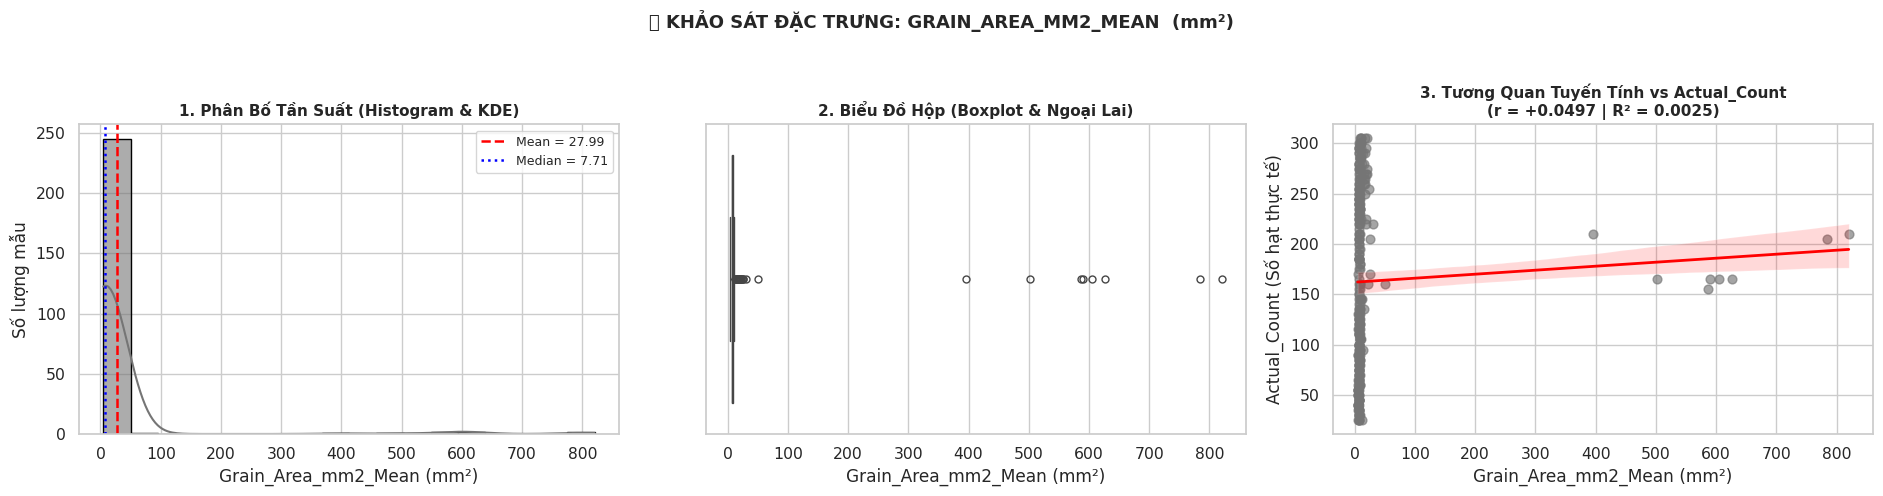

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Area_mm2_Mean             (mm²)     N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 27.99    | Std = 108.38   | Min = 4.83     | Max = 820.22       │
│  • Tứ phân vị (IQR) : 25% = 6.99      | Median = 7.71   | 75% = 8.97     | Skewness = 5.76   │
│  • Tương quan Tuyến : Pearson r = +0.0497  (R² = 0.0025) | Spearman rho = +0.5072  (p = 4.30e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 0.03976 * X + 161.98 | MAE = 76.82 hạt (MAPE = 85.80%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



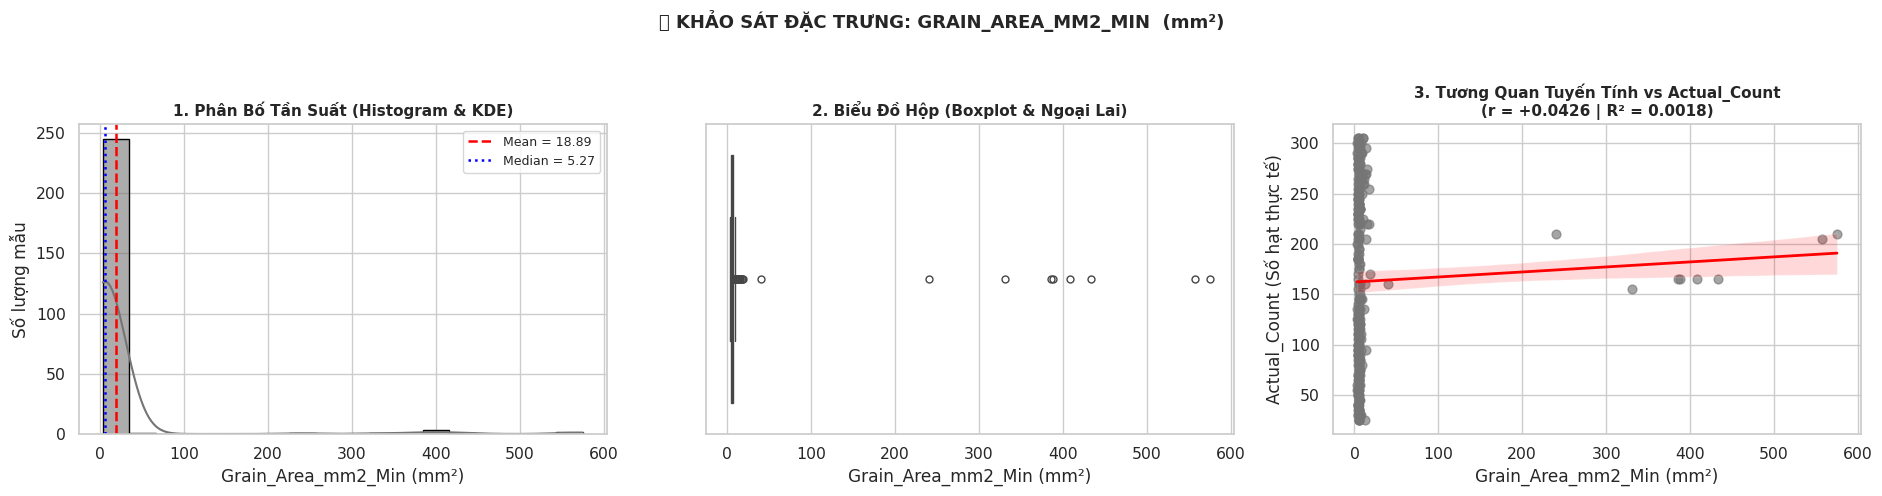

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Area_mm2_Min              (mm²)     N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 18.89    | Std = 73.94    | Min = 3.10     | Max = 575.11       │
│  • Tứ phân vị (IQR) : 25% = 4.55      | Median = 5.27   | 75% = 6.22     | Skewness = 5.90   │
│  • Tương quan Tuyến : Pearson r = +0.0426  (R² = 0.0018) | Spearman rho = +0.0499  (p = 4.99e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 0.04998 * X + 162.15 | MAE = 76.83 hạt (MAPE = 85.87%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



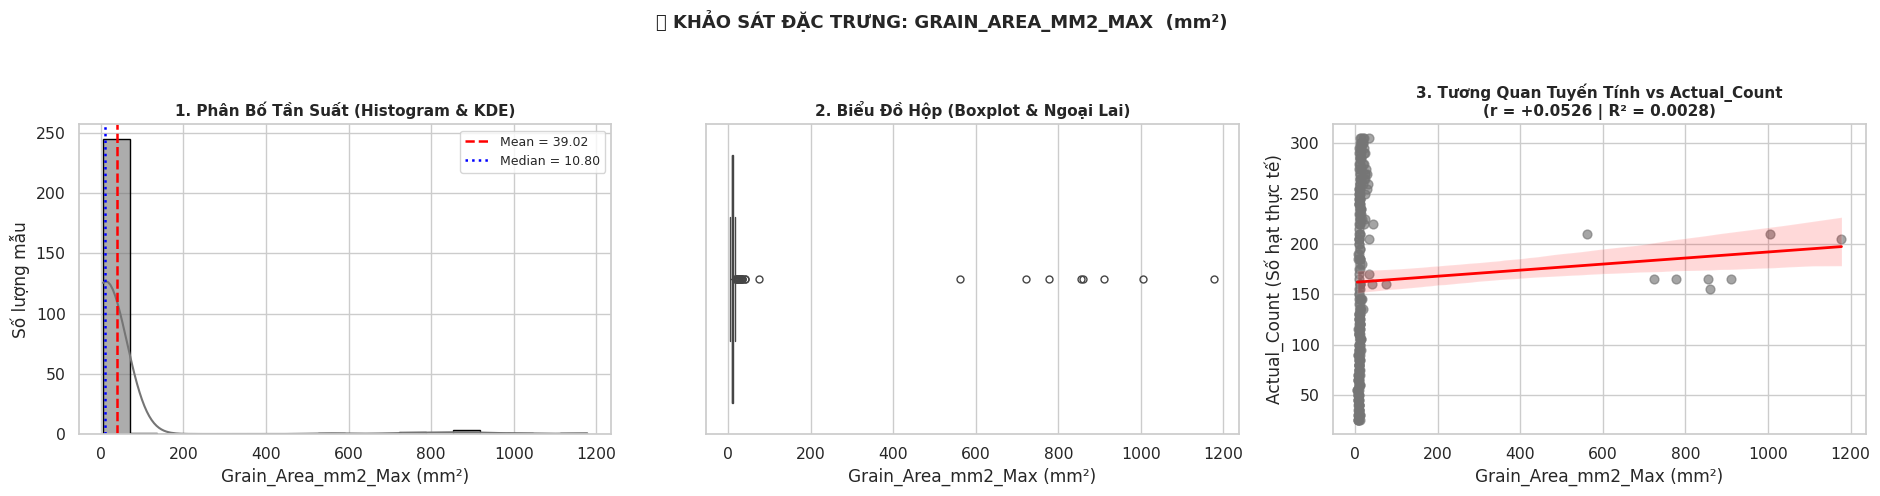

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Area_mm2_Max              (mm²)     N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 39.02    | Std = 151.45   | Min = 5.11     | Max = 1178.13      │
│  • Tứ phân vị (IQR) : 25% = 9.21      | Median = 10.80  | 75% = 12.69    | Skewness = 5.73   │
│  • Tương quan Tuyến : Pearson r = +0.0526  (R² = 0.0028) | Spearman rho = +0.6147  (p = 4.04e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 0.03010 * X + 161.92 | MAE = 76.82 hạt (MAPE = 85.76%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



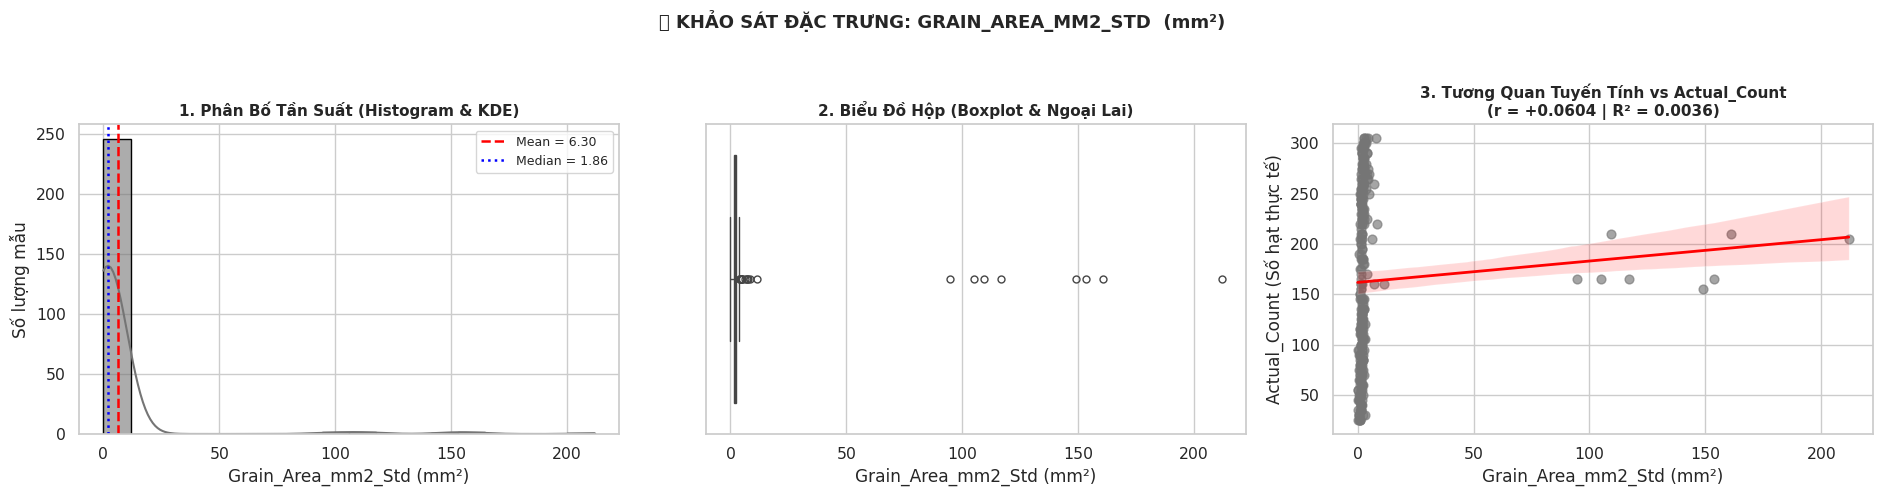

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Area_mm2_Std              (mm²)     N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 6.30     | Std = 24.63    | Min = 0.00     | Max = 211.84       │
│  • Tứ phân vị (IQR) : 25% = 1.40      | Median = 1.86   | 75% = 2.39     | Skewness = 6.01   │
│  • Tương quan Tuyến : Pearson r = +0.0604  (R² = 0.0036) | Spearman rho = +0.5246  (p = 3.38e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 0.21262 * X + 161.75 | MAE = 76.75 hạt (MAPE = 85.65%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



In [20]:
# =============================================================================
# NHÓM 6: DIỆN TÍCH 2D HẠT NGUYÊN (AREA) (4 THUỘC TÍNH: MEAN, MIN, MAX, STD)
# =============================================================================
print("=" * 95)
print("🔲 BẮT ĐẦU KHẢO SÁT NHÓM 6: DIỆN TÍCH 2D HẠT NGUYÊN (AREA)")
print("=" * 95 + "\n")

# 1. Diện tích 2D trung bình hạt (Grain_Area_mm2_Mean)
inspect_single_feature(df, 'Grain_Area_mm2_Mean', 'Diện tích 2D trung bình hạt nguyên', 'mm²')

# 2. Diện tích nhỏ nhất (Grain_Area_mm2_Min)
inspect_single_feature(df, 'Grain_Area_mm2_Min', 'Diện tích hạt nhỏ nhất trong mẫu', 'mm²')

# 3. Diện tích lớn nhất (Grain_Area_mm2_Max)
inspect_single_feature(df, 'Grain_Area_mm2_Max', 'Diện tích hạt lớn nhất trong mẫu', 'mm²')

# 4. Độ lệch chuẩn diện tích (Grain_Area_mm2_Std)
inspect_single_feature(df, 'Grain_Area_mm2_Std', 'Độ biến thiên diện tích giữa các hạt', 'mm²')


🌐 BẮT ĐẦU KHẢO SÁT NHÓM 7: THỂ TÍCH 3D ELLIPSOID HẠT NGUYÊN (VOLUME)



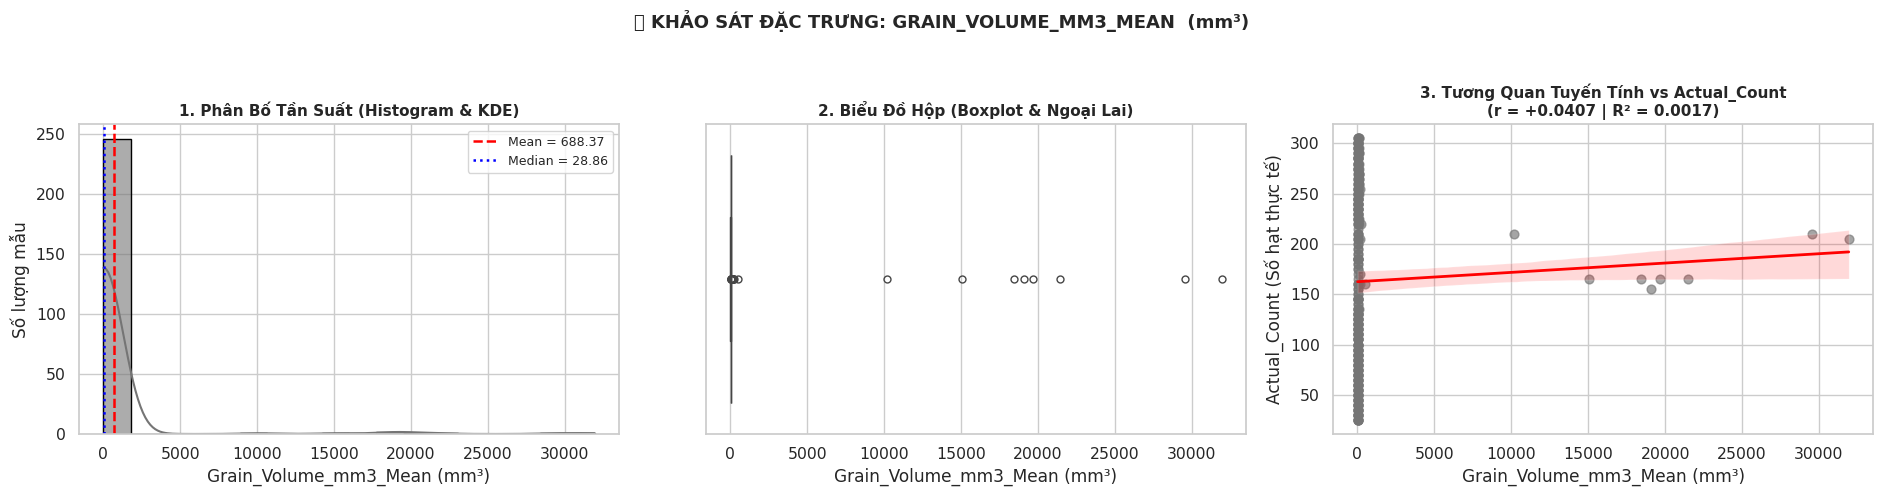

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Volume_mm3_Mean           (mm³)     N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 688.37   | Std = 3800.05  | Min = 11.90    | Max = 31932.16     │
│  • Tứ phân vị (IQR) : 25% = 24.44     | Median = 28.86  | 75% = 35.63    | Skewness = 6.23   │
│  • Tương quan Tuyến : Pearson r = +0.0407  (R² = 0.0017) | Spearman rho = +0.5206  (p = 5.19e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 0.00093 * X + 162.45 | MAE = 76.81 hạt (MAPE = 85.88%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



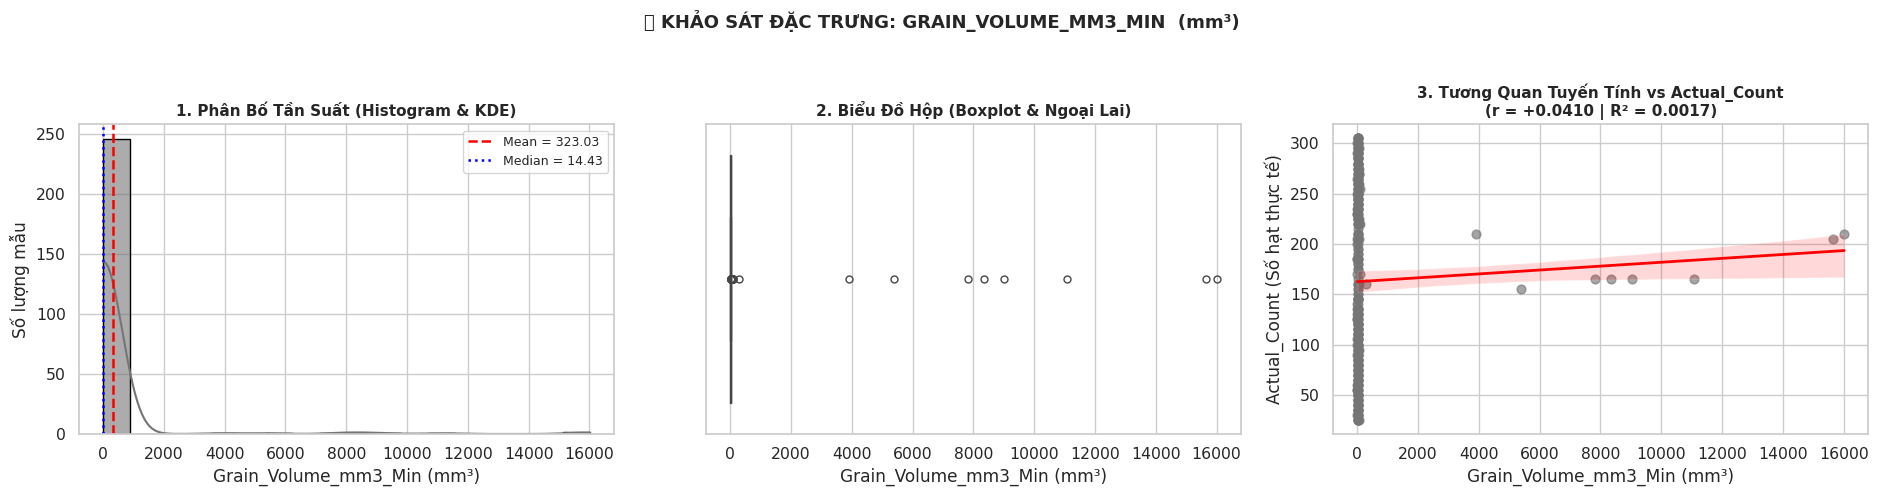

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Volume_mm3_Min            (mm³)     N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 323.03   | Std = 1838.16  | Min = 6.11     | Max = 16016.57     │
│  • Tứ phân vị (IQR) : 25% = 11.42     | Median = 14.43  | 75% = 19.21    | Skewness = 6.73   │
│  • Tương quan Tuyến : Pearson r = +0.0410  (R² = 0.0017) | Spearman rho = +0.0274  (p = 5.15e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 0.00193 * X + 162.47 | MAE = 76.78 hạt (MAPE = 85.88%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



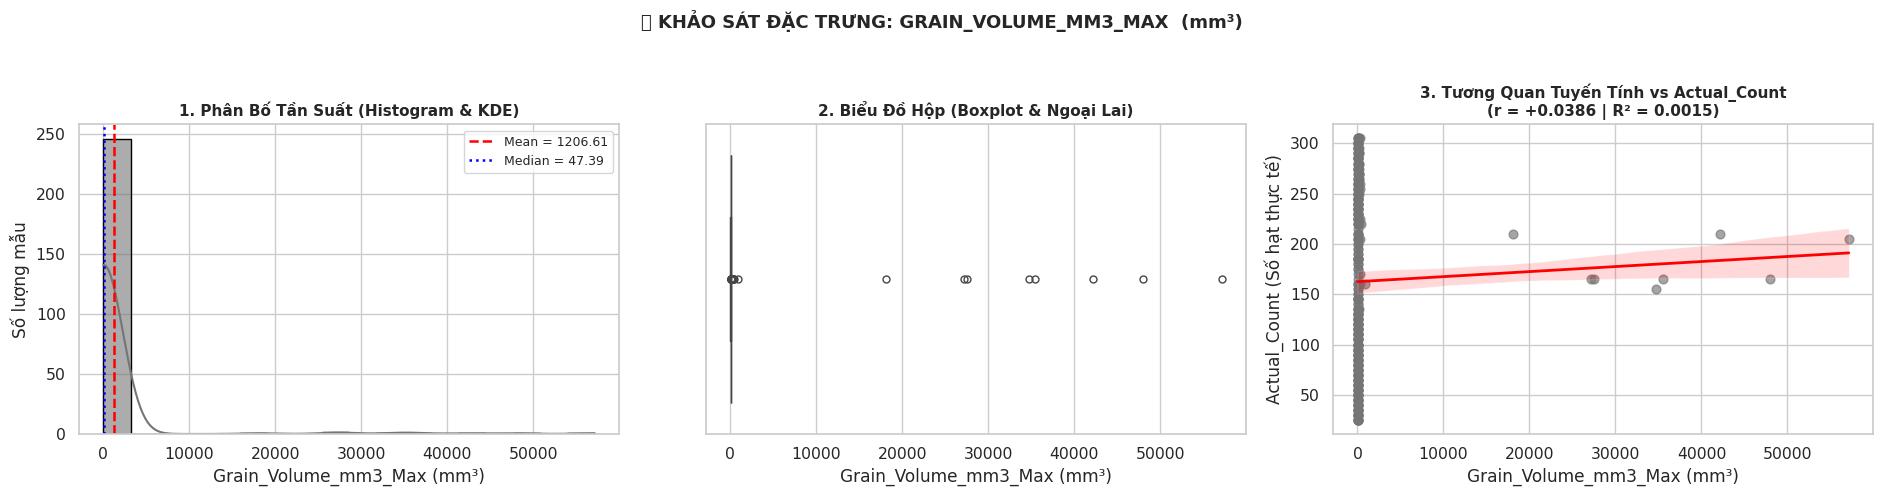

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Volume_mm3_Max            (mm³)     N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 1206.61  | Std = 6674.56  | Min = 14.28    | Max = 57121.36     │
│  • Tứ phân vị (IQR) : 25% = 37.14     | Median = 47.39  | 75% = 61.47    | Skewness = 6.22   │
│  • Tương quan Tuyến : Pearson r = +0.0386  (R² = 0.0015) | Spearman rho = +0.6190  (p = 5.41e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 0.00050 * X + 162.49 | MAE = 76.84 hạt (MAPE = 85.91%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



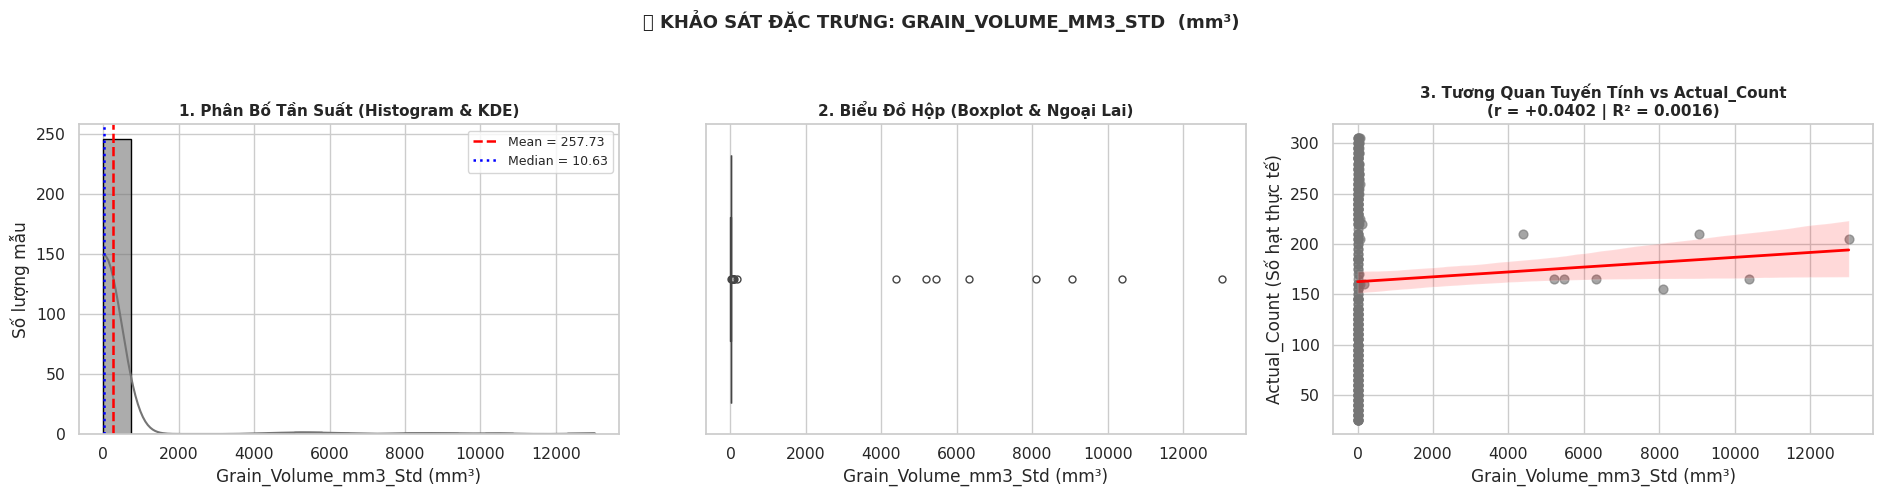

┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ 📋 THÔNG SỐ CHI TIẾT: Grain_Volume_mm3_Std            (mm³)     N = 254  mẫu                       │
├────────────────────────────────────────────────────────────────────────────────────────────┤
│  • Thống kê phân bố : Mean = 257.73   | Std = 1439.18  | Min = 0.00     | Max = 13024.39     │
│  • Tứ phân vị (IQR) : 25% = 8.09      | Median = 10.63  | 75% = 15.07    | Skewness = 6.45   │
│  • Tương quan Tuyến : Pearson r = +0.0402  (R² = 0.0016) | Spearman rho = +0.5493  (p = 5.23e-01) │
│  • Hồi quy Đơn biến : Actual_Count = 0.00242 * X + 162.47 | MAE = 76.81 hạt (MAPE = 85.89%)  │
│  • Đánh giá mức độ  : ⚪ YẾU / NHIỄU (Không nên dùng độc lập)                                │
└────────────────────────────────────────────────────────────────────────────────────────────┘



In [21]:
# =============================================================================
# NHÓM 7: THỂ TÍCH 3D ELLIPSOID HẠT NGUYÊN (VOLUME) (4 THUỘC TÍNH: MEAN, MIN, MAX, STD)
# =============================================================================
print("=" * 95)
print("🌐 BẮT ĐẦU KHẢO SÁT NHÓM 7: THỂ TÍCH 3D ELLIPSOID HẠT NGUYÊN (VOLUME)")
print("=" * 95 + "\n")

# 1. Thể tích 3D trung bình hạt (Grain_Volume_mm3_Mean)
inspect_single_feature(df, 'Grain_Volume_mm3_Mean', 'Thể tích 3D Ellipsoid trung bình 1 hạt', 'mm³')

# 2. Thể tích nhỏ nhất (Grain_Volume_mm3_Min)
inspect_single_feature(df, 'Grain_Volume_mm3_Min', 'Thể tích hạt nhỏ nhất trong mẫu', 'mm³')

# 3. Thể tích lớn nhất (Grain_Volume_mm3_Max)
inspect_single_feature(df, 'Grain_Volume_mm3_Max', 'Thể tích hạt lớn nhất trong mẫu', 'mm³')

# 4. Độ lệch chuẩn thể tích (Grain_Volume_mm3_Std)
inspect_single_feature(df, 'Grain_Volume_mm3_Std', 'Độ biến thiên thể tích giữa các hạt', 'mm³')


🏆 BẢNG TỔNG HỢP XẾP HẠNG TOÀN BỘ 31 ĐẶC TRƯNG GỐC THEO R² VỚI Actual_Count:


,Thuộc_Tính (Feature),Nhóm_Phân_Loại,Pearson_r,R2_Score,Spearman_rho,MAE_Đơn_Biến,MAPE_Đơn_Biến_%,p_value,Mức_Độ_Tương_Quan
1,Weight_g,Vật chứa & Khối lúa,0.9986,0.9973,0.9991,2.86,3.11,0.00e+00,🌟 Cực kỳ mạnh
2,Bulk_Rice_Volume_mm3,Thể tích 3D Hạt,0.9959,0.9918,0.9980,5.74,6.06,1.22e-264,🌟 Cực kỳ mạnh
3,Rice_Height_mm,Vật chứa & Khối lúa,0.8835,0.7805,0.9088,33.62,27.68,5.99e-85,🌟 Cực kỳ mạnh
4,Inner_Diameter_mm,Vật chứa & Khối lúa,0.8828,0.7793,0.8655,34.55,34.25,1.21e-84,🌟 Cực kỳ mạnh
5,Container_Height_mm,Vật chứa & Khối lúa,0.8828,0.7793,0.8655,34.55,34.25,1.21e-84,🌟 Cực kỳ mạnh
6,Empty_Height_mm,Vật chứa & Khối lúa,-0.8019,0.6431,-0.8109,44.75,33.26,2.60e-58,🟢 Rất mạnh
7,Whole_Grains_Count,Bề mặt & Ước lượng,0.7946,0.6313,0.8039,41.85,38.87,1.57e-56,🟢 Rất mạnh
8,Estimated_Total_Seeds_Hybrid,Bề mặt & Ước lượng,0.6440,0.4147,0.6337,53.40,52.45,3.76e-31,🟢 Rất mạnh
9,Container_Detected_Diam_px,Vật chứa & Khối lúa,0.4291,0.1841,0.4817,66.41,74.38,8.47e-13,🟠 Trung bình
10,Grain_Length_mm_Std,Chiều dài 2a,0.1567,0.0245,0.4876,76.59,83.99,1.24e-02,⚪ Yếu / Nhiễu


💾 Đã lưu bảng xếp hạng chi tiết vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DATASET_BUILDER/4_Final_Dataset/all_features_correlation_report.csv


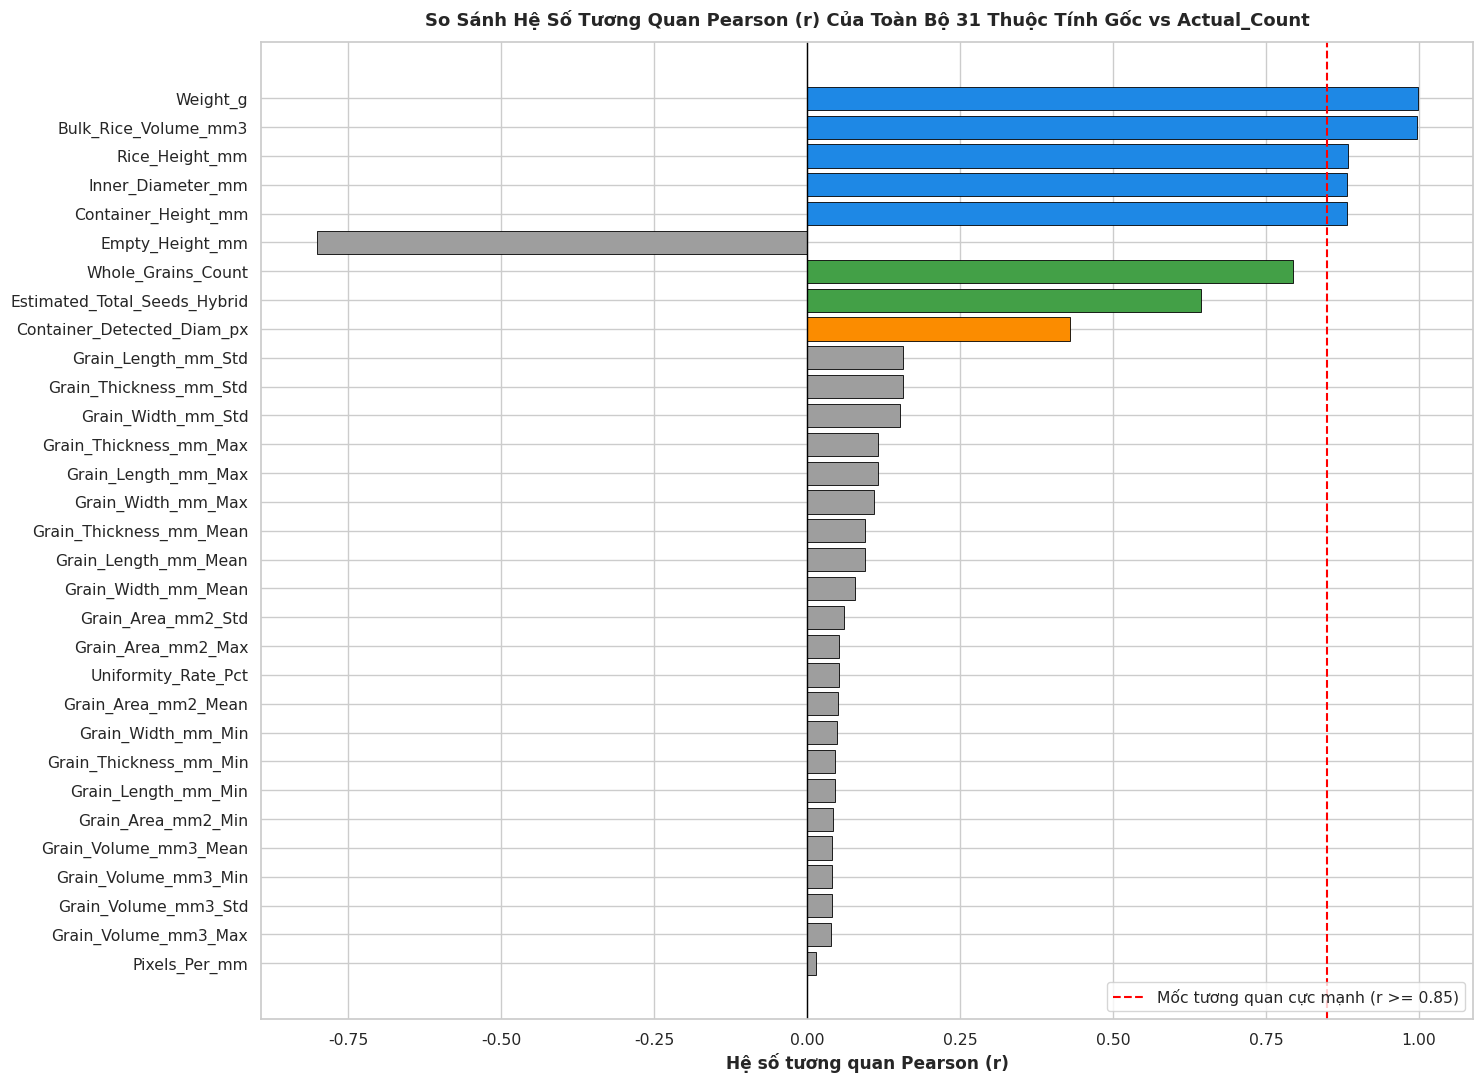

💾 Đã lưu biểu đồ xếp hạng vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DATASET_BUILDER/4_Final_Dataset/all_features_ranking_chart.png


In [22]:
# =============================================================================
# NHÓM 8: BẢNG TỔNG KẾT XẾP HẠNG & SO SÁNH TOÀN BỘ 31 THUỘC TÍNH GỐC
# =============================================================================
summary_rows = []

for feat in ALL_FEATURES:
    sub_df = df[[feat, 'Actual_Count']].dropna()
    if len(sub_df) > 10:
        x = sub_df[feat]
        y = sub_df['Actual_Count']

        r_val, p_val = stats.pearsonr(x, y)
        rho_val, _   = stats.spearmanr(x, y)
        r2_val       = r_val ** 2

        # Hồi quy đơn biến sơ bộ
        slope, intercept = np.polyfit(x, y, 1)
        pred_y = slope * x + intercept
        mae_v  = float(np.mean(np.abs(pred_y - y)))
        mape_v = float(np.mean(np.abs((pred_y - y) / y)) * 100)

        # Phân loại nhóm
        if 'Length' in feat:
            group_name = "Chiều dài 2a"
        elif 'Width' in feat:
            group_name = "Chiều rộng 2b"
        elif 'Thickness' in feat:
            group_name = "Chiều dày 2c"
        elif 'Area' in feat:
            group_name = "Diện tích 2D"
        elif 'Volume_mm3' in feat:
            group_name = "Thể tích 3D Hạt"
        elif 'Bulk' in feat or 'Height' in feat or 'Diam' in feat or 'Pixels' in feat or 'Weight' in feat:
            group_name = "Vật chứa & Khối lúa"
        else:
            group_name = "Bề mặt & Ước lượng"

        summary_rows.append({
            'Thuộc_Tính (Feature)': feat,
            'Nhóm_Phân_Loại': group_name,
            'Pearson_r': round(r_val, 4),
            'R2_Score': round(r2_val, 4),
            'Spearman_rho': round(rho_val, 4),
            'MAE_Đơn_Biến': round(mae_v, 2),
            'MAPE_Đơn_Biến_%': round(mape_v, 2),
            'p_value': f"{p_val:.2e}",
            'Mức_Độ_Tương_Quan': '🌟 Cực kỳ mạnh' if abs(r_val) >= 0.85 else
                                 '🟢 Rất mạnh' if abs(r_val) >= 0.60 else
                                 '🟠 Trung bình' if abs(r_val) >= 0.35 else '⚪ Yếu / Nhiễu'
        })

df_leaderboard = pd.DataFrame(summary_rows).sort_values(by='R2_Score', ascending=False).reset_index(drop=True)
df_leaderboard.index = df_leaderboard.index + 1

print("=" * 105)
print("🏆 BẢNG TỔNG HỢP XẾP HẠNG TOÀN BỘ 31 ĐẶC TRƯNG GỐC THEO R² VỚI Actual_Count:")
print("=" * 105)
display(df_leaderboard)

# Xuất báo cáo tổng kết ra CSV
out_report_path = os.path.join(BASE_PATH, "DATASET_BUILDER/4_Final_Dataset/all_features_correlation_report.csv")
df_leaderboard.to_csv(out_report_path, encoding="utf-8-sig")
print(f"💾 Đã lưu bảng xếp hạng chi tiết vào: {out_report_path}")

# Vẽ Biểu Đồ Thanh Ngang Toàn Bộ 31 Features
plt.figure(figsize=(15, 11))
colors = ['#1E88E5' if r >= 0.85 else '#43A047' if r >= 0.60 else '#FB8C00' if r >= 0.35 else '#9E9E9E' for r in df_leaderboard['Pearson_r']]

plt.barh(df_leaderboard['Thuộc_Tính (Feature)'][::-1], df_leaderboard['Pearson_r'][::-1], color=colors[::-1], edgecolor='black', linewidth=0.6)
plt.axvline(0, color='black', linewidth=1)
plt.axvline(0.85, color='red', linestyle='--', linewidth=1.5, label='Mốc tương quan cực mạnh (r >= 0.85)')
plt.title("So Sánh Hệ Số Tương Quan Pearson (r) Của Toàn Bộ 31 Thuộc Tính Gốc vs Actual_Count", fontweight='bold', fontsize=13, pad=12)
plt.xlabel("Hệ số tương quan Pearson (r)", fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
chart_path = os.path.join(BASE_PATH, "DATASET_BUILDER/4_Final_Dataset/all_features_ranking_chart.png")
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Đã lưu biểu đồ xếp hạng vào: {chart_path}")
